# Чекпоинт 6: DL-модели — улучшение бейзлайна (v2, исправленная)

В чекпоинте 5 получили "лучшее" решение (**SimpleLSTM**, без утечки данных, веса классов + early stopping) и провели серию экспериментов с RNN / CNN / Transformer / регрессией / triple-barrier разметкой. Ключевые выводы:

- наивная бинарная разметка знака доходности (1m и 15m) ведёт к торговле «каждого микродвижения» → Sharpe сильно отрицательный;
- **экономически осмысленная разметка** (triple-barrier по волатильности) и **регрессия + порог уверенности** радикально улучшают Sharpe;
- ROC-AUC моделей держится в районе **0.51–0.59** — типично для крипторынка, поэтому метрики качества классификации сами по себе слабо коррелируют с торговой прибылью.

Из изначального плана относятся к чекпоинту 6 — *работа по улучшению результата бейзлайна за счёт RL / self-supervised / contrastive learning*, а также ещё направления из предыдущего чекпоинта:

1. **Meta-Labeling** (López de Prado): базовая модель даёт направление, мета-модель — вероятность успеха и размер позиции.
2. **Custom Loss**: дифференцируемая аппроксимация Sharpe / PnL вместо CrossEntropy/MSE.
3. **Учёт транзакционных издержек** (комиссии + проскальзывание) прямо в подборе порога и в метриках.
4. **Self-supervised / contrastive предобучение** энкодера временных рядов.

---

### План чекпоинта

| Часть | Подход | Цель / тип обучения |
|-------|--------|---------------------|
| 0 | Импорты, конфиг, утилиты из CP5 | воспроизводимость |
| 1 | Реалистичная оценка с транзакционными издержками + **forward-return утилиты** | честный Sharpe / PnL |
| 1b | **Зоопарк новых архитектур + фабрика build_model** | расширение поиска |
| 1c | **Перебор гиперпараметров (Random Search по val net-Sharpe)** | автоматический выбор лучшей архитектуры |
| 2 | **Self-Supervised предобучение** (masked reconstruction) + дообучение головы | representation learning |
| 3 | **Contrastive предобучение** (NT-Xent) энкодера | representation learning |
| 4 | **Custom Differentiable Sharpe Loss** + forward-return вознаграждение | end-to-end торговая модель |
| 5 | **Meta-Labeling** (первичная модель + мета-модель размера) | снижение просадок |
| 6 | **Deep RL** агент (DQN) long/flat, 8–10 эпизодов | reinforcement learning |
| 7 | Итоговое сравнение всех подходов CP5+CP6 по Sharpe / PnL / ROC-AUC | выводы |


## 0. Импорты, конфигурация и утилиты из CP5

In [2]:
from pathlib import Path
import os, sys, gc, math, pickle, ast, warnings, random

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
from IPython.display import display
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, mean_squared_error, mean_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader, Dataset, TensorDataset

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.ml_model import SimpleLSTM  # эталон из бейзлайна/CP5

DATA_DIR = Path(os.environ.get("ML_DATA_DIR", ROOT / "data" / "processed"))
MODELS_DIR = Path(os.environ.get("ML_MODELS_DIR", ROOT / "models"))
MODELS_DIR.mkdir(parents=True, exist_ok=True)

ACTIVE_ASSET = "BTC"
ASSETS = ["BTC", "ETH", "BNB", "SOL", "XRP"]
WINDOW_SIZE = 60
BATCH_SIZE = 256
BATCH_SIZE_HEAVY = min(BATCH_SIZE, 128)
LR = 1e-3
EPOCHS = 30
PATIENCE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.2
SEED = 42

# Горизонт forward-return (совпадает с VERTICAL_TB, чтобы таргет и оценка были на одном горизонте)
HORIZON = 15          # баров; меняйте вместе с VERTICAL_TB
MIN_HOLDING = HORIZON  # минимальное удержание позиции (баров) — снижает число сделок

PER_YEAR_1M = 60 * 24 * 365
PER_YEAR_15M = (60 * 24 * 365) / 15
# Оценка стратегии ведётся на горизонте HORIZON: частота = PER_YEAR_1M / HORIZON
PER_YEAR_FWD = PER_YEAR_1M / HORIZON

# Транзакционные издержки (реалистично для крипто-спота, taker fee ~ 5-10 bps + проскальзывание)
FEE_BPS = 5.0          # комиссия в базисных пунктах за одну сделку (вход/выход)
SLIPPAGE_BPS = 2.0     # проскальзывание в базисных пунктах
COST_PER_TURN = (FEE_BPS + SLIPPAGE_BPS) / 1e4  # доля от позиции при смене позиции

# Параметр бюджета перебора гиперпараметров
SEARCH_BUDGET = 10     # число случайных конфигураций; уменьшите для ускорения
N_SEARCH_EPOCHS = 8    # эпохи внутри поиска (быстрый вариант)
N_SEARCH_PATIENCE = 3  # early stopping внутри поиска

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.92)
print("device:", device)
print("models dir:", MODELS_DIR)

device: cuda
models dir: D:\study\master_ai\mastercoursework\master-coursework\models


In [ ]:
def load_splits(data_dir: Path):
    return (
        pd.read_parquet(data_dir / "X_train.parquet"),
        pd.read_parquet(data_dir / "y_train.parquet"),
        pd.read_parquet(data_dir / "X_val.parquet"),
        pd.read_parquet(data_dir / "y_val.parquet"),
        pd.read_parquet(data_dir / "X_test.parquet"),
        pd.read_parquet(data_dir / "y_test.parquet"),
    )


def resolve_y_column(df: pd.DataFrame, asset: str, name: str = "y_bin"):
    key = (asset, name)
    if key in df.columns:
        return key
    for c in df.columns:
        if c == key:
            return c
        if isinstance(c, str) and c.startswith("("):
            try:
                if ast.literal_eval(c) == key:
                    return c
            except (ValueError, SyntaxError):
                pass
    raise KeyError(f"Нет таргета {key}. Примеры колонок: {list(df.columns)[:10]}")


class WindowDataset(Dataset):
    def __init__(self, X, y, window):
        self.window = window
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        seqs, labs = [], []
        for i in range(window, len(X)):
            seqs.append(self.X[i - window:i]); labs.append(self.y[i])
        self.sequences = np.stack(seqs, axis=0)
        self.labels = np.array(labs, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx]), torch.tensor(self.labels[idx], dtype=torch.long)


def sharpe_ratio(log_returns, periods_per_year):
    log_returns = pd.Series(log_returns)
    if len(log_returns) == 0 or log_returns.std() == 0:
        return 0.0
    return float(log_returns.mean() / log_returns.std() * np.sqrt(periods_per_year))


def triple_barrier_labels(r, vol_window, pt_mult, sl_mult, vertical, eps=1e-8):
    r = r.astype(float).sort_index()
    vals = r.values; n = len(vals)
    out = np.full(n, np.nan)
    for pos in range(vol_window, n - vertical + 1):
        sig = float(vals[pos - vol_window:pos].std()) or eps
        if sig < eps: sig = eps
        upper, lower = pt_mult * sig, -sl_mult * sig
        cum, lab = 0.0, 0
        for k in range(vertical):
            cum += vals[pos + k]
            if cum >= upper: lab = 1; break
            if cum <= lower: lab = 0; break
        else:
            lab = 0
        out[pos] = lab
    return pd.Series(out, index=r.index)


def train_epoch(model, loader, criterion, optimizer):
    model.train(); tot, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    return tot / max(n, 1)


@torch.no_grad()
def roc_auc_logits(model, loader):
    model.eval(); ys, sc = [], []
    for xb, yb in loader:
        ys.append(yb.numpy()); sc.append(model(xb.to(device))[:, 1].cpu().numpy())
    if not ys: return 0.5
    try:
        return roc_auc_score(np.concatenate(ys), np.concatenate(sc))
    except ValueError:
        return 0.5


@torch.no_grad()
def predict_labels_probs(model, loader):
    model.eval(); preds, ys, probs = [], [], []
    for xb, yb in loader:
        logits = model(xb.to(device))
        probs.append(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        preds.append(torch.argmax(logits, 1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(ys), np.concatenate(probs)


def fit_classifier(model, train_loader, val_loader, criterion, optimizer,
                   epochs=EPOCHS, patience=PATIENCE, tag=""):
    """Обучение с early stopping по val ROC-AUC (как в CP5, сохранён для совместимости)."""
    best_auc, best_state, stale = -1.0, None, 0
    for ep in range(1, epochs + 1):
        tl = train_epoch(model, train_loader, criterion, optimizer)
        va = roc_auc_logits(model, val_loader)
        print(f"[{tag}] {ep:02d}/{epochs} loss={tl:.4f} val_auc={va:.4f}")
        if va > best_auc:
            best_auc, best_state, stale = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            stale += 1
            if stale >= patience:
                print(f"[{tag}] early stopping"); break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_auc


# --- Сохранение моделей в MODELS_DIR с осмысленными именами ---
def _infer_input_size(model, default=None):
    """Безопасно определяет input_size из самой модели (первый LSTM/GRU/Conv/Linear),
    не обращаясь к глобальным переменным и к model.<attr>."""
    for m in model.modules():
        if isinstance(m, (nn.LSTM, nn.GRU)):
            return int(m.input_size)
    for m in model.modules():
        if isinstance(m, nn.Conv1d):
            return int(m.in_channels)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            return int(m.in_features)
    return default


def _infer_hidden_size(model, default=None):
    for m in model.modules():
        if isinstance(m, (nn.LSTM, nn.GRU)):
            return int(m.hidden_size)
    return default


def save_torch_model(model, filename, extra=None):
    """Сохраняет state_dict torch-модели + метаданные в models/<filename>.

    Размеры берём из самой модели (а не из глобальных переменных), чтобы избежать
    AttributeError '... object has no attribute n_features' при разных способах запуска.
    """
    path = MODELS_DIR / filename
    payload = {"state_dict": model.state_dict(),
               "class_name": type(model).__name__,
               "input_size": _infer_input_size(model, default=globals().get("n_features")),
               "window_size": globals().get("WINDOW_SIZE"),
               "hidden_size": _infer_hidden_size(model, default=globals().get("HIDDEN_SIZE"))}
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"[saved] {path}")
    return path


def save_sklearn_model(model, filename, extra=None):
    """Сохраняет sklearn-модель (+ метаданные) в models/<filename>.pkl"""
    path = MODELS_DIR / filename
    with open(path, "wb") as f:
        pickle.dump({"model": model, "meta": extra or {}}, f)
    print(f"[saved] {path}")
    return path

## 1. Реалистичная оценка с транзакционными издержками и forward-return утилиты

### 1.1 Утилиты forward-return и фильтрации позиций

Новые инструменты:

- **`forward_return(y_reg, H)`** — суммарная log-доходность за следующие H баров (rolling forward sum).  
  Позволяет оценивать стратегию на том же горизонте, что и обучающий сигнал (HORIZON=15).  
  Без этого: модель оптимизирована на 15-барный барьер, а Sharpe считается на 1-минутном возврате — несоответствие горизонтов убивает статистику.

- **`apply_min_holding(positions, min_hold)`** — после открытия позиции держим её минимум `min_hold` баров,  
  не переключаясь. Снижает число сделок с O(N) до O(N/H) → издержки падают в H раз.

- **`apply_hysteresis(prob, enter_thr, exit_thr)`** — два порога: входим при `prob >= enter_thr`,  
  выходим при `prob < exit_thr`, иначе держим прежнюю позицию. Устраняет «дёргание» у границы одного порога.

- **`tune_threshold(prob_val, fwd_val, idx_val, ...)`** — перебирает пороги и min_hold по val net-Sharpe;  
  возвращает лучшие параметры. Всё подобранное — только на val, финальная оценка — на test.

- **`evaluate_on_forward`** — обёртка `evaluate_strategy` для оценки на forward-return горизонта H.

In [3]:
def net_returns(positions: pd.Series, asset_returns: pd.Series, cost_per_turn=COST_PER_TURN):
    """Чистая доходность стратегии long/flat с учётом издержек на смену позиции.
    positions: 0/1 (или доля капитала) на каждый шаг; asset_returns: log-returns актива.
    """
    positions = positions.reindex(asset_returns.index).fillna(0.0)
    gross = positions * asset_returns
    turn = positions.diff().abs().fillna(positions.abs())   # объём переключений
    cost = turn * cost_per_turn
    return gross - cost


def forward_return(y_reg_series: pd.Series, horizon: int) -> pd.Series:
    """Суммарная log-доходность за следующие `horizon` баров (без утечки).

    r_fwd[t] = sum(r[t+1], ..., r[t+horizon])
    Последние `horizon` значений будут NaN (нет достаточно будущих баров).
    Используется и для создания меток, и для оценки стратегии — горизонт согласован.

    Реализация: rolling(horizon).sum() вычисляет скользящую сумму за horizon баров назад,
    shift(-horizon) сдвигает результат на horizon шагов назад → получаем сумму ВПЕРЁД.
    r.rolling(H).sum().shift(-H) at position t = r[t+1] + ... + r[t+H]. ✓
    """
    r = y_reg_series.astype(float)
    fwd = r.rolling(window=horizon, min_periods=horizon).sum().shift(-horizon)
    return fwd


def apply_min_holding(positions: pd.Series, min_hold: int) -> pd.Series:
    """Постобработка позиций: после открытия позиции удерживаем её min_hold баров.

    Алгоритм: сканируем последовательно; при изменении позиции фиксируем и не меняем
    следующие min_hold-1 баров.
    Снижает число сделок примерно в min_hold раз → издержки падают пропорционально.
    """
    vals = positions.values.copy()
    n = len(vals)
    hold_counter = 0
    current_pos = vals[0] if n > 0 else 0
    out = np.empty(n, dtype=float)
    for i in range(n):
        if hold_counter > 0:
            out[i] = current_pos
            hold_counter -= 1
        else:
            if vals[i] != current_pos:
                current_pos = vals[i]
                hold_counter = min_hold - 1
            out[i] = current_pos
    return pd.Series(out, index=positions.index)


def apply_hysteresis(prob: np.ndarray, enter_thr: float, exit_thr: float) -> np.ndarray:
    """Два порога для бинарного сигнала: входим при prob>=enter_thr, выходим при prob<exit_thr.

    При prob in [exit_thr, enter_thr) — держим прежнюю позицию (гистерезис).
    Устраняет 'дёргание' у одного порога, снижает число сделок.
    """
    n = len(prob)
    out = np.zeros(n, dtype=float)
    pos = 0.0
    for i in range(n):
        p = float(prob[i])
        if p >= enter_thr:
            pos = 1.0
        elif p < exit_thr:
            pos = 0.0
        # иначе: держим pos
        out[i] = pos
    return out


def tune_threshold(prob_val: np.ndarray, fwd_val: pd.Series, idx_val,
                   periods_per_year: float = PER_YEAR_FWD,
                   thr_grid=None, hold_options=None, mode: str = "simple"):
    """Перебирает пороги (и опционально min_hold / гистерезис) по val net-Sharpe.

    mode='simple'    — один порог, один min_hold
    mode='hysteresis' — enter_thr / exit_thr (enter_thr = t, exit_thr = t - gap)

    Возвращает dict с лучшими параметрами и достигнутым val net-Sharpe.
    ВСЁ подбирается ТОЛЬКО на val — финальная оценка выполняется на test снаружи.
    """
    if thr_grid is None:
        thr_grid = np.linspace(0.30, 0.72, 43)
    if hold_options is None:
        hold_options = [1, HORIZON]

    best_sh = -1e18
    best_params = {"threshold": 0.5, "min_hold": 1, "val_net_sharpe": -1e18}
    fwd_series = pd.Series(fwd_val.values, index=idx_val[:len(fwd_val)])

    if mode == "simple":
        for t in thr_grid:
            raw_pos = pd.Series((prob_val >= t).astype(float), index=idx_val[:len(prob_val)])
            for mh in hold_options:
                pos = apply_min_holding(raw_pos, mh)
                pos_aligned = pos.reindex(fwd_series.index).fillna(0.0)
                sh = sharpe_ratio(net_returns(pos_aligned, fwd_series), periods_per_year)
                if sh > best_sh:
                    best_sh = sh
                    best_params = {"threshold": float(t), "min_hold": int(mh),
                                   "val_net_sharpe": float(sh)}
    elif mode == "hysteresis":
        gaps = [0.05, 0.10, 0.15]
        for t in thr_grid:
            for gap in gaps:
                exit_t = max(0.0, t - gap)
                raw = apply_hysteresis(prob_val, enter_thr=t, exit_thr=exit_t)
                raw_pos = pd.Series(raw, index=idx_val[:len(prob_val)])
                for mh in hold_options:
                    pos = apply_min_holding(raw_pos, mh)
                    pos_aligned = pos.reindex(fwd_series.index).fillna(0.0)
                    sh = sharpe_ratio(net_returns(pos_aligned, fwd_series), periods_per_year)
                    if sh > best_sh:
                        best_sh = sh
                        best_params = {"threshold": float(t), "exit_thr": float(exit_t),
                                       "min_hold": int(mh), "val_net_sharpe": float(sh)}
    return best_params


def evaluate_strategy(positions, asset_returns, periods_per_year, name="strategy",
                      prob=None, true_label=None):
    """Информативная оценка торговой стратегии с жёстким выравниванием индексов.

    ВАЖНО (исправление бага): раньше при рассинхроне длин positions и asset_returns
    reindex тихо заполнял NaN нулями → метрики "схлопывались" в 0 или в Buy&Hold.
    Теперь работаем только по общему индексу и диагностируем вырожденные позиции.
    """
    positions = pd.Series(positions).astype(float)
    asset_returns = pd.Series(asset_returns).astype(float)
    common = positions.index.intersection(asset_returns.index)
    if len(common) == 0:
        # индексы не совпадают — выравниваем позиционно (одинаковый порядок)
        m = min(len(positions), len(asset_returns))
        positions = pd.Series(positions.values[:m], index=asset_returns.index[:m])
        common = positions.index
    pos = positions.reindex(common).fillna(0.0)
    ret = asset_returns.reindex(common).fillna(0.0)

    gross = pos * ret
    turn = pos.diff().abs().fillna(pos.abs())
    net = gross - turn * COST_PER_TURN
    n_trades = int(turn.sum())

    frac_long = float((pos > 0).mean())
    n_unique_pos = int(pd.unique(np.round(pos.values, 4)).size)
    degenerate = (n_unique_pos <= 1)   # позиция не меняется → или всё 0 (Sharpe~0), или всё 1 (=B&H)

    res = {
        "Стратегия": name,
        "Sharpe gross": round(sharpe_ratio(gross, periods_per_year), 4),
        "Sharpe net": round(sharpe_ratio(net, periods_per_year), 4),
        "PnL net (sum logret)": round(float(net.sum()), 5),
        "% времени в long": round(100 * frac_long, 1),
        "Сделок (смен позиции)": n_trades,
        "Вырождена?": "ДА" if degenerate else "нет",
    }
    if prob is not None and true_label is not None:
        prob = np.asarray(prob); true_label = np.asarray(true_label)
        try:
            res["ROC-AUC"] = round(float(roc_auc_score(true_label, prob)), 4)
        except ValueError:
            res["ROC-AUC"] = float("nan")
        # hit-rate на входах: доля прибыльных ставок (ret>0 там, где были в long)
        in_pos = pos.values > 0
        if in_pos.sum() > 0:
            res["Hit-rate входов"] = round(100 * float((ret.values[in_pos] > 0).mean()), 1)
        else:
            res["Hit-rate входов"] = float("nan")
    return res


def evaluate_on_forward(positions: pd.Series, fwd_series: pd.Series,
                        name: str = "strategy", prob=None, true_label=None):
    """Оценка стратегии на forward-return горизонта HORIZON (не на 1-минутном ret).

    Позиции и fwd_series должны быть выровнены по индексу.
    periods_per_year для forward-return = PER_YEAR_1M / HORIZON.
    """
    return evaluate_strategy(positions, fwd_series, PER_YEAR_FWD,
                             name=name, prob=prob, true_label=true_label)

### 1.2 Тренер с early stopping по val net-Sharpe

`fit_classifier_sharpe` — новый тренер, заменяющий `fit_classifier` для основных моделей CP6.

**Отличие от старого:** на каждой эпохе после train-loss вычисляем val net-Sharpe на forward-return
(а не ROC-AUC). Early stopping и выбор лучшей эпохи — по val net-Sharpe.
Для диагностики логируем и AUC, и Sharpe. Старый `fit_classifier` сохранён для совместимости.

In [ ]:
def fit_classifier_sharpe(model, train_loader, val_loader, criterion, optimizer,
                          fwd_val: pd.Series, idx_val_w,
                          epochs=EPOCHS, patience=PATIENCE, tag="",
                          periods_per_year=PER_YEAR_FWD, min_hold=1):
    """Обучение с early stopping по val net-Sharpe на forward-return (исправление причины #2).

    Вместо ROC-AUC (бесполезен при AUC~0.51-0.55) отбираем эпоху по торговой метрике:
    val net-Sharpe, рассчитанному на forward-return горизонта HORIZON.
    fwd_val  — pd.Series forward-return на val (без утечки, уже вычислен).
    idx_val_w — индекс val-окон (выровнен с предсказаниями модели).
    """
    best_sh, best_state, stale = -1e18, None, 0
    fwd_s = pd.Series(fwd_val.values[:len(idx_val_w)], index=idx_val_w)
    for ep in range(1, epochs + 1):
        tl = train_epoch(model, train_loader, criterion, optimizer)
        va_auc = roc_auc_logits(model, val_loader)
        # вычисляем val net-Sharpe для отбора
        _, _, p1v = predict_labels_probs(model, val_loader)
        n_p = min(len(p1v), len(idx_val_w))
        raw_pos = pd.Series((p1v[:n_p] >= 0.5).astype(float), index=idx_val_w[:n_p])
        pos_mh = apply_min_holding(raw_pos, min_hold) if min_hold > 1 else raw_pos
        pos_aligned = pos_mh.reindex(fwd_s.index).fillna(0.0)
        val_sh = sharpe_ratio(net_returns(pos_aligned, fwd_s), periods_per_year)
        print(f"[{tag}] {ep:02d}/{epochs} loss={tl:.4f} val_auc={va_auc:.4f} val_netSharpe={val_sh:.3f}")
        if val_sh > best_sh:
            best_sh = val_sh
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print(f"[{tag}] early stopping (val net-Sharpe не растёт)"); break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_sh


def fit_classifier(model, train_loader, val_loader, criterion, optimizer,
                   epochs=EPOCHS, patience=PATIENCE, tag=""):
    """Обучение с early stopping по val ROC-AUC (как в CP5)."""
    best_auc, best_state, stale = -1.0, None, 0
    for ep in range(1, epochs + 1):
        tl = train_epoch(model, train_loader, criterion, optimizer)
        va = roc_auc_logits(model, val_loader)
        print(f"[{tag}] {ep:02d}/{epochs} loss={tl:.4f} val_auc={va:.4f}")
        if va > best_auc:
            best_auc, best_state, stale = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            stale += 1
            if stale >= patience:
                print(f"[{tag}] early stopping"); break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_auc

## 2. Данные и triple-barrier разметка (как лучший таргет CP5)

В предыдущем чекпоинте именно triple-barrier дал лучший Sharpe, поэтому в этом чекпоинте предобучение и торговые модели
строим на этом таргете для BTC.

**Новое:** `HORIZON = VERTICAL_TB = 15` вынесен в общий параметр. Вычисляем `fwd_tr/va/te`
(forward-return на горизонте HORIZON) для оценки всех стратегий — теперь горизонт таргета
и горизонт оценки совпадают.

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)

prefix = f"{ACTIVE_ASSET}__"
feat_cols = [c for c in X_train.columns if str(c).startswith(prefix)]
n_features = len(feat_cols)

# --- triple-barrier (минутные log-returns y_reg) ---
# HORIZON совпадает с VERTICAL_TB (причина #1: выравнивание горизонтов)
VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB = 60, 1.0, 1.0, HORIZON

s_tr = y_train[resolve_y_column(y_train, ACTIVE_ASSET, "y_reg")].dropna()
s_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].dropna()
s_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].dropna()

tb_tr = triple_barrier_labels(s_tr, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_va = triple_barrier_labels(s_va, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)
tb_te = triple_barrier_labels(s_te, VOL_WINDOW_TB, PT_MULT, SL_MULT, VERTICAL_TB)

ix_tr = tb_tr.dropna().index.intersection(X_train[feat_cols].index)
ix_va = tb_va.dropna().index.intersection(X_val[feat_cols].index)
ix_te = tb_te.dropna().index.intersection(X_test[feat_cols].index)

Xt_tb = X_train[feat_cols].loc[ix_tr]; Xv_tb = X_val[feat_cols].loc[ix_va]; Xte_tb = X_test[feat_cols].loc[ix_te]
yt_tb = tb_tr.loc[ix_tr].astype(np.int64).values
yv_tb = tb_va.loc[ix_va].astype(np.int64).values
yte_tb = tb_te.loc[ix_te].astype(np.int64).values

# fit scaler ТОЛЬКО на train (без утечки)
scaler_tb = StandardScaler()
Xt_s = scaler_tb.fit_transform(Xt_tb)
Xv_s = scaler_tb.transform(Xv_tb)
Xte_s = scaler_tb.transform(Xte_tb)

ds_tr = WindowDataset(Xt_s, yt_tb, WINDOW_SIZE)
ds_va = WindowDataset(Xv_s, yv_tb, WINDOW_SIZE)
ds_te = WindowDataset(Xte_s, yte_tb, WINDOW_SIZE)
ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
ld_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False)
ld_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False)

ct = np.bincount(ds_tr.labels, minlength=2)
cw = ct.sum() / (2 * np.maximum(ct, 1))
w_tb = torch.tensor(cw, dtype=torch.float32)

# --- forward-return на горизонте HORIZON (для оценки стратегий, исправление причины #1) ---
# Вычисляем ТОЛЬКО на соответствующих y_reg сериях, без утечки test → val → train
fwd_tr_full = forward_return(s_tr, HORIZON)
fwd_va_full = forward_return(s_va, HORIZON)
fwd_te_full = forward_return(s_te, HORIZON)

# Индексы окон (после WINDOW_SIZE баров)
idx_te = Xte_tb.index[WINDOW_SIZE: WINDOW_SIZE + len(ds_te)]
idx_va_w = Xv_tb.index[WINDOW_SIZE: WINDOW_SIZE + len(ds_va)]
idx_tr_w = Xt_tb.index[WINDOW_SIZE: WINDOW_SIZE + len(ds_tr)]

# forward-return выровненный по окнам (для оценки стратегий)
fwd_te = fwd_te_full.reindex(idx_te).fillna(0.0)
fwd_va = fwd_va_full.reindex(idx_va_w).fillna(0.0)
fwd_tr_w = fwd_tr_full.reindex(idx_tr_w).fillna(0.0)

# 1-минутная доходность (для WindowReturnDataset и совместимости)
y_reg_te = y_test[resolve_y_column(y_test, ACTIVE_ASSET, "y_reg")].reindex(idx_te).fillna(0.0)
y_reg_va = y_val[resolve_y_column(y_val, ACTIVE_ASSET, "y_reg")].reindex(idx_va_w).fillna(0.0)

display(pd.DataFrame([{
    "n_features": n_features, "train_windows": len(ds_tr),
    "val_windows": len(ds_va), "test_windows": len(ds_te),
    "class_counts": ct.tolist(),
    "HORIZON": HORIZON, "MIN_HOLDING": MIN_HOLDING,
}]))

# Buy & Hold с учётом издержек — считаем на forward-return (референс)
bh_pos = pd.Series(1.0, index=idx_te)
bh_eval = evaluate_on_forward(bh_pos, fwd_te, name="#0 Buy & Hold (forward-ret H={})".format(HORIZON))
display(pd.DataFrame([bh_eval]))

,n_features,train_windows,val_windows,test_windows,class_counts,HORIZON,MIN_HOLDING
0,15,348347,175546,1304,"[174683, 173664]",15,15


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,#0 Buy & Hold (forward-ret H=15),9.4865,9.4498,0.18207,100.0,1,ДА


## 2b. Зоопарк архитектур (не только LSTM)

Добавляем пять новых архитектур. Все принимают вход `(B, T, F)` и возвращают логиты `(B, 2)`.
Каждая параметризована через `hidden`, `num_layers`, `dropout` — единообразно для random search.

- **GRUClassifier** — GRU вместо LSTM (меньше параметров, часто быстрее сходится).
- **BiLSTMAttnClassifier** — двунаправленный LSTM + attention-pooling (взвешенное среднее по времени вместо last step).
- **TCNClassifier** — Temporal Convolutional Network: стек dilated causal conv1d + residual connection.
- **TransformerClassifier** — проекция + позиционное кодирование + nn.TransformerEncoder + mean-pooling.
- **CNNLSTMClassifier** — Conv1d feature extractor → LSTM → голова.

Фабрика `build_model(name, n_features, **hp)` создаёт любую архитектуру по имени.

In [ ]:
# ============================================================
# Зоопарк архитектур (вход (B,T,F), выход логиты (B,2)) 
# Все размеры передаём через конструктор и сохраняем в обычных атрибутах
# без конфликта с nn.Module.
# ============================================================

class GRUClassifier(nn.Module):
    """GRU-классификатор: (B,T,F) -> логиты (B,2)."""
    def __init__(self, input_size: int, hidden: int = 64, num_layers: int = 1,
                 dropout: float = 0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.gru(x)           # (B, T, H)
        h = out[:, -1, :]              # последний шаг
        return self.fc(self.drop(h))   # (B, 2)


class BiLSTMAttnClassifier(nn.Module):
    """Двунаправленный LSTM + attention-pooling по времени -> логиты (B,2)."""
    def __init__(self, input_size: int, hidden: int = 64, num_layers: int = 1,
                 dropout: float = 0.2):
        super().__init__()
        self.bilstm = nn.LSTM(input_size, hidden, num_layers, batch_first=True,
                              bidirectional=True,
                              dropout=dropout if num_layers > 1 else 0.0)
        self.attn_w = nn.Linear(hidden * 2, 1)   # attention-score по каждому шагу
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, 2)

    def forward(self, x):
        out, _ = self.bilstm(x)                     # (B, T, 2H)
        scores = self.attn_w(out).squeeze(-1)        # (B, T)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, T, 1)
        pooled = (out * weights).sum(dim=1)          # (B, 2H) — взвешенный avg
        return self.fc(self.drop(pooled))            # (B, 2)


class _TCNBlock(nn.Module):
    """Один резидуальный блок TCN: dilated causal Conv1d + residual."""
    def __init__(self, n_channels: int, kernel_size: int, dilation: int, dropout: float):
        super().__init__()
        pad = (kernel_size - 1) * dilation   # causal padding
        self.conv1 = nn.Conv1d(n_channels, n_channels, kernel_size,
                               padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(n_channels, n_channels, kernel_size,
                               padding=pad, dilation=dilation)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self._pad = pad

    def _causal_crop(self, x):
        """Обрезаем правую padding-часть, чтобы выход совпадал по длине с входом."""
        if self._pad > 0:
            x = x[:, :, :-self._pad]
        return x

    def forward(self, x):
        # x: (B, C, T)
        residual = x
        out = self.relu(self._causal_crop(self.conv1(x)))
        out = self.drop(out)
        out = self.relu(self._causal_crop(self.conv2(out)))
        out = self.drop(out)
        return self.relu(out + residual)


class TCNClassifier(nn.Module):
    """Temporal Convolutional Network: dilated causal conv + residual -> логиты (B,2).
    Вход (B,T,F) -> transpose -> стек TCN-блоков -> avg-pool -> FC."""
    def __init__(self, input_size: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.2, kernel_size: int = 3):
        super().__init__()
        self.proj = nn.Conv1d(input_size, hidden, kernel_size=1)
        blocks = []
        for i in range(num_layers):
            dilation = 2 ** i
            blocks.append(_TCNBlock(hidden, kernel_size, dilation, dropout))
        self.tcn = nn.Sequential(*blocks)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x):
        # x: (B, T, F)
        x = x.transpose(1, 2)          # (B, F, T)
        x = self.proj(x)               # (B, H, T)
        x = self.tcn(x)                # (B, H, T)
        x = x.mean(dim=2)              # (B, H) — avg-pool по времени
        return self.fc(self.drop(x))   # (B, 2)


class TransformerClassifier(nn.Module):
    """Transformer-классификатор: projection + pos-encoding + TransformerEncoder + mean-pool -> (B,2)."""
    def __init__(self, input_size: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.2, nhead: int = 4):
        super().__init__()
        # nhead должен делить hidden нацело; если нет — подбираем ближайший
        while hidden % nhead != 0 and nhead > 1:
            nhead -= 1
        self.proj = nn.Linear(input_size, hidden)
        self.dropout_emb = nn.Dropout(dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=hidden, nhead=nhead,
                                               dim_feedforward=hidden * 4,
                                               dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 2)
        self._hidden = hidden

    def _pos_encoding(self, T: int, device) -> torch.Tensor:
        """Синусоидальное позиционное кодирование (B-независимое)."""
        pe = torch.zeros(T, self._hidden, device=device)
        pos = torch.arange(0, T, device=device).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, self._hidden, 2, device=device).float()
                        * (-math.log(10000.0) / self._hidden))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:self._hidden // 2])
        return pe.unsqueeze(0)   # (1, T, H)

    def forward(self, x):
        # x: (B, T, F)
        B, T, _ = x.shape
        h = self.proj(x)                             # (B, T, H)
        h = self.dropout_emb(h + self._pos_encoding(T, x.device))
        h = self.transformer(h)                      # (B, T, H)
        h = h.mean(dim=1)                            # (B, H) — mean-pool
        return self.fc(self.drop(h))                 # (B, 2)


class CNNLSTMClassifier(nn.Module):
    """CNN feature extractor -> LSTM -> голова. Вход (B,T,F) -> (B,2)."""
    def __init__(self, input_size: int, hidden: int = 64, num_layers: int = 1,
                 dropout: float = 0.2, cnn_channels: int = 32, kernel_size: int = 3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, cnn_channels, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(cnn_channels, hidden, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, 2)

    def forward(self, x):
        # x: (B, T, F)
        c = self.cnn(x.transpose(1, 2))   # (B, C, T)
        c = c.transpose(1, 2)             # (B, T, C)
        out, _ = self.lstm(c)             # (B, T, H)
        h = out[:, -1, :]                 # (B, H)
        return self.fc(self.drop(h))      # (B, 2)


def build_model(name: str, n_features_in: int, **hp) -> nn.Module:
    """Фабрика моделей по имени.

    name: 'gru' | 'bilstm_attn' | 'tcn' | 'transformer' | 'cnn_lstm' | 'simple_lstm'
    hp:   hidden, num_layers, dropout (и любые специфичные параметры)
    Все модели: вход (B, T, F), выход логиты (B, 2).
    """
    hidden = int(hp.get("hidden", 64))
    num_layers = int(hp.get("num_layers", 1))
    dropout = float(hp.get("dropout", 0.2))
    if name == "gru":
        return GRUClassifier(n_features_in, hidden=hidden, num_layers=num_layers, dropout=dropout)
    elif name == "bilstm_attn":
        return BiLSTMAttnClassifier(n_features_in, hidden=hidden, num_layers=num_layers, dropout=dropout)
    elif name == "tcn":
        return TCNClassifier(n_features_in, hidden=hidden, num_layers=num_layers, dropout=dropout)
    elif name == "transformer":
        return TransformerClassifier(n_features_in, hidden=hidden, num_layers=num_layers, dropout=dropout)
    elif name == "cnn_lstm":
        return CNNLSTMClassifier(n_features_in, hidden=hidden, num_layers=num_layers, dropout=dropout)
    elif name == "simple_lstm":
        return SimpleLSTM(input_size=n_features_in, hidden_size=hidden,
                          num_layers=num_layers, dropout=dropout)
    else:
        raise ValueError(f"Неизвестная архитектура: {name!r}. "
                         "Доступны: gru, bilstm_attn, tcn, transformer, cnn_lstm, simple_lstm")

print("Зоопарк архитектур загружен. build_model готов к использованию.")
print("Архитектуры:", ["gru", "bilstm_attn", "tcn", "transformer", "cnn_lstm", "simple_lstm"])

Зоопарк архитектур загружен. build_model готов к использованию.
Архитектуры: ['gru', 'bilstm_attn', 'tcn', 'transformer', 'cnn_lstm', 'simple_lstm']


## 2c. Перебор гиперпараметров (Random Search)

**Стратегия поиска** (отбор по торговой метрике — причина #2 + #4):

- Пространство: `arch × hidden × num_layers × dropout × lr × weight_decay`
- SEARCH_BUDGET (по умолчанию 10) случайных конфигураций с фиксированным seed.
- Каждая конфигурация: `N_SEARCH_EPOCHS` эпох с `fit_classifier_sharpe` (early stopping по val net-Sharpe).
- После N_SEARCH_EPOCHS подбираем оптимальный порог и min_hold по val net-Sharpe.
- Выбираем ЛУЧШУЮ конфигурацию по val net-Sharpe → оцениваем на test → сохраняем модель.

**Защита от утечек:**
- scaler уже fit на train, трогать нельзя;
- fwd_va вычислен из y_val (не из test);
- порог/min_hold — только на val;
- итог — только на test.

In [7]:
import itertools

SEARCH_SPACE = {
    "arch":        ["gru", "bilstm_attn", "tcn", "transformer", "cnn_lstm", "simple_lstm"],
    "hidden":      [32, 64, 128],
    "num_layers":  [1, 2],
    "dropout":     [0.1, 0.3],
    "lr":          [3e-4, 1e-3],
    "weight_decay": [0.0, 1e-5],
}

# Генерируем SEARCH_BUDGET случайных конфигов (воспроизводимо через SEED)
rng_search = np.random.default_rng(SEED)
def _sample_config(rng):
    return {k: rng.choice(v).item() if isinstance(rng.choice(v), np.generic) else rng.choice(v)
            for k, v in SEARCH_SPACE.items()}

configs = [_sample_config(rng_search) for _ in range(SEARCH_BUDGET)]
print(f"Random search: {SEARCH_BUDGET} конфигураций, {N_SEARCH_EPOCHS} эпох каждая")
display(pd.DataFrame(configs))

Random search: 10 конфигураций, 8 эпох каждая


,arch,hidden,num_layers,dropout,lr,weight_decay
0,cnn_lstm,64,2,0.3,0.0003,0.00001
1,cnn_lstm,128,1,0.1,0.0003,0.00001
2,transformer,128,1,0.1,0.0010,0.00000
3,cnn_lstm,64,2,0.1,0.0010,0.00001
4,cnn_lstm,32,1,0.1,0.0003,0.00001
5,cnn_lstm,128,1,0.1,0.0003,0.00000
6,gru,64,1,0.3,0.0003,0.00001
7,cnn_lstm,32,2,0.3,0.0003,0.00000
8,cnn_lstm,32,1,0.1,0.0010,0.00001
9,cnn_lstm,128,1,0.3,0.0003,0.00000


In [8]:
search_results = []

for cfg_idx, cfg in enumerate(configs):
    arch = cfg["arch"]
    hp = {k: cfg[k] for k in ("hidden", "num_layers", "dropout")}
    lr_cfg = float(cfg["lr"])
    wd_cfg = float(cfg["weight_decay"])
    tag = f"SRCH[{cfg_idx+1}/{SEARCH_BUDGET}] {arch} h={cfg['hidden']} l={cfg['num_layers']} d={cfg['dropout']:.1f}"
    print(f"\n{'='*60}\n{tag}")

    torch.manual_seed(SEED + cfg_idx)
    model_cfg = build_model(arch, n_features, **hp).to(device)
    crit_cfg = nn.CrossEntropyLoss(weight=w_tb.to(device))
    opt_cfg = optim.Adam(model_cfg.parameters(), lr=lr_cfg, weight_decay=wd_cfg)

    val_sh = fit_classifier_sharpe(
        model_cfg, ld_tr, ld_va, crit_cfg, opt_cfg,
        fwd_val=fwd_va, idx_val_w=idx_va_w,
        epochs=N_SEARCH_EPOCHS, patience=N_SEARCH_PATIENCE,
        tag=tag, periods_per_year=PER_YEAR_FWD, min_hold=MIN_HOLDING,
    )

    # Подбираем порог + min_hold на val (без test!)
    _, _, p1v_cfg = predict_labels_probs(model_cfg, ld_va)
    best_p = tune_threshold(p1v_cfg, fwd_va, idx_va_w,
                            periods_per_year=PER_YEAR_FWD,
                            hold_options=[1, MIN_HOLDING], mode="simple")
    row = {**cfg, "val_net_sharpe": val_sh, **{f"best_{k}": v for k, v in best_p.items()}}
    search_results.append(row)
    print(f"  => val_net_sharpe={val_sh:.4f}  best_thr={best_p['threshold']:.2f}  min_hold={best_p['min_hold']}")
    del model_cfg; gc.collect()

search_df = pd.DataFrame(search_results).sort_values("val_net_sharpe", ascending=False).reset_index(drop=True)
display(search_df)
search_df.to_csv(MODELS_DIR / "cp6_hparam_search.csv", index=False)
print("Таблица поиска сохранена:", MODELS_DIR / "cp6_hparam_search.csv")


SRCH[1/10] cnn_lstm h=64 l=2 d=0.3
[SRCH[1/10] cnn_lstm h=64 l=2 d=0.3] 01/8 loss=0.6927 val_auc=0.5135 val_netSharpe=0.583
[SRCH[1/10] cnn_lstm h=64 l=2 d=0.3] 02/8 loss=0.6924 val_auc=0.5135 val_netSharpe=-1.019
[SRCH[1/10] cnn_lstm h=64 l=2 d=0.3] 03/8 loss=0.6923 val_auc=0.5126 val_netSharpe=-1.471
[SRCH[1/10] cnn_lstm h=64 l=2 d=0.3] 04/8 loss=0.6922 val_auc=0.5130 val_netSharpe=-1.035
[SRCH[1/10] cnn_lstm h=64 l=2 d=0.3] early stopping (val net-Sharpe не растёт)
  => val_net_sharpe=0.5833  best_thr=0.42  min_hold=15

SRCH[2/10] cnn_lstm h=128 l=1 d=0.1
[SRCH[2/10] cnn_lstm h=128 l=1 d=0.1] 01/8 loss=0.6925 val_auc=0.5140 val_netSharpe=0.246
[SRCH[2/10] cnn_lstm h=128 l=1 d=0.1] 02/8 loss=0.6923 val_auc=0.5132 val_netSharpe=-0.814
[SRCH[2/10] cnn_lstm h=128 l=1 d=0.1] 03/8 loss=0.6921 val_auc=0.5134 val_netSharpe=1.089
[SRCH[2/10] cnn_lstm h=128 l=1 d=0.1] 04/8 loss=0.6920 val_auc=0.5123 val_netSharpe=-0.033
[SRCH[2/10] cnn_lstm h=128 l=1 d=0.1] 05/8 loss=0.6919 val_auc=0.5133 va

,arch,hidden,num_layers,dropout,lr,weight_decay,val_net_sharpe,best_threshold,best_min_hold,best_val_net_sharpe
0,transformer,128,1,0.1,0.0010,0.00000,1.301182,0.44,15,2.782600
1,cnn_lstm,128,1,0.1,0.0003,0.00000,1.266060,0.40,15,2.778969
2,cnn_lstm,64,2,0.1,0.0010,0.00001,1.199012,0.30,1,2.760517
3,cnn_lstm,128,1,0.1,0.0003,0.00001,1.089417,0.44,15,3.054311
4,cnn_lstm,32,2,0.3,0.0003,0.00000,0.752671,0.43,15,2.830247
5,cnn_lstm,64,2,0.3,0.0003,0.00001,0.583294,0.42,15,2.783833
6,cnn_lstm,128,1,0.3,0.0003,0.00000,0.540651,0.41,15,3.101419
7,cnn_lstm,32,1,0.1,0.0003,0.00001,0.196392,0.40,15,3.142947
8,gru,64,1,0.3,0.0003,0.00001,0.051900,0.43,15,2.906683
9,cnn_lstm,32,1,0.1,0.0010,0.00001,-0.275498,0.30,1,2.760517


Таблица поиска сохранена: D:\study\master_ai\mastercoursework\master-coursework\models\cp6_hparam_search.csv


In [9]:
# Переобучаем лучшую конфигурацию с полным числом эпох и оцениваем на test
best_row = search_df.iloc[0]
best_arch = best_row["arch"]
best_hp = {k: best_row[k] for k in ("hidden", "num_layers", "dropout")}
best_lr = float(best_row["lr"])
best_wd = float(best_row["weight_decay"])
best_thr_search = float(best_row["best_threshold"])
best_mh_search = int(best_row["best_min_hold"])

print(f"\nЛучшая конфигурация: {best_arch}, hp={best_hp}, lr={best_lr}, wd={best_wd}")
print(f"  val_net_sharpe={best_row['val_net_sharpe']:.4f}, thr={best_thr_search:.2f}, min_hold={best_mh_search}")

torch.manual_seed(SEED)
best_model = build_model(best_arch, n_features, **best_hp).to(device)
crit_best = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_best = optim.Adam(best_model.parameters(), lr=best_lr, weight_decay=best_wd)

fit_classifier_sharpe(
    best_model, ld_tr, ld_va, crit_best, opt_best,
    fwd_val=fwd_va, idx_val_w=idx_va_w,
    epochs=EPOCHS, patience=PATIENCE,
    tag=f"BEST-{best_arch}", periods_per_year=PER_YEAR_FWD, min_hold=best_mh_search,
)

# Оцениваем на test (порог из val, не трогаем!)
pred_best, ytrue_best, p1_best = predict_labels_probs(best_model, ld_te)
raw_pos_best = pd.Series((p1_best >= best_thr_search).astype(float), index=idx_te[:len(p1_best)])
pos_best = apply_min_holding(raw_pos_best, best_mh_search)
search_eval = evaluate_on_forward(
    pos_best, fwd_te,
    name=f"#BestTuned {best_arch} (t={best_thr_search:.2f}, mh={best_mh_search})",
    prob=p1_best, true_label=ytrue_best,
)
display(pd.DataFrame([search_eval]))

save_torch_model(best_model, f"best_{best_arch}_tuned.pt",
                 extra={"threshold": best_thr_search, "min_hold": best_mh_search,
                        "val_net_sharpe": float(best_row["val_net_sharpe"]),
                        "hp": dict(best_hp)})


Лучшая конфигурация: transformer, hp={'hidden': np.int64(128), 'num_layers': np.int64(1), 'dropout': np.float64(0.1)}, lr=0.001, wd=0.0
  val_net_sharpe=1.3012, thr=0.44, min_hold=15
[BEST-transformer] 01/30 loss=0.6940 val_auc=0.5090 val_netSharpe=0.481
[BEST-transformer] 02/30 loss=0.6926 val_auc=0.5117 val_netSharpe=-1.284
[BEST-transformer] 03/30 loss=0.6925 val_auc=0.5099 val_netSharpe=1.525
[BEST-transformer] 04/30 loss=0.6924 val_auc=0.5087 val_netSharpe=0.695
[BEST-transformer] 05/30 loss=0.6922 val_auc=0.5098 val_netSharpe=1.689
[BEST-transformer] 06/30 loss=0.6922 val_auc=0.5079 val_netSharpe=1.204
[BEST-transformer] 07/30 loss=0.6920 val_auc=0.5090 val_netSharpe=1.827
[BEST-transformer] 08/30 loss=0.6919 val_auc=0.5081 val_netSharpe=1.293
[BEST-transformer] 09/30 loss=0.6919 val_auc=0.5085 val_netSharpe=0.186
[BEST-transformer] 10/30 loss=0.6918 val_auc=0.5078 val_netSharpe=1.011
[BEST-transformer] 11/30 loss=0.6917 val_auc=0.5079 val_netSharpe=-0.135
[BEST-transformer] 12/

,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,"#BestTuned transformer (t=0.44, mh=15)",-18.651,-20.9164,-0.21726,27.8,34,нет,0.4696,50.4


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\best_transformer_tuned.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/best_transformer_tuned.pt')

## 3. Self-Supervised предобучение: masked reconstruction

**Идея.** На крипторынке размеченные таргеты слабопредсказуемы (ROC-AUC ~0.51), но *самих окон* очень много. Self-supervised learning (SSL) позволяет выучить полезное представление временного ряда **без меток**, а затем дообучить лёгкую голову на маленьком размеченном сигнале — это снижает переобучение и улучшает обобщение.

**Метод (masked reconstruction, в духе TST / BERT-for-TS).** Маскируем случайные таймстемпы во входном окне и обучаем LSTM-энкодер + линейный декодер восстанавливать исходные значения.

**Оценка:** дообученная SSL-модель оценивается на **forward-return горизонта HORIZON** с min_holding.

In [10]:
class LSTMEncoder(nn.Module):
    """Общий энкодер: LSTM -> представление последовательности (h_t для каждого шага и финальное)."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, num_layers=1, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.hidden_size = hidden_size

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, H)
        return out                      # представления по всем шагам


class MaskedReconstructionModel(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.decoder = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        return self.decoder(self.encoder(x))   # реконструкция (B, T, F)


def mask_batch(xb, mask_ratio=0.15):
    """Случайно зануляем mask_ratio таймстемпов; возвращаем испорченный вход и маску."""
    B, T, Fdim = xb.shape
    mask = (torch.rand(B, T, device=xb.device) < mask_ratio).unsqueeze(-1)  # (B,T,1)
    corrupted = xb.masked_fill(mask, 0.0)
    return corrupted, mask.float()


def pretrain_masked(model, loader, epochs=15, lr=1e-3, tag="SSL-mask"):
    model.to(device); opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, _ in loader:
            xb = xb.to(device)
            corrupted, mask = mask_batch(xb)
            recon = model(corrupted)
            # MSE только по замаскированным позициям
            loss = ((recon - xb) ** 2 * mask).sum() / (mask.sum() * xb.size(-1) + 1e-8)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0); n += xb.size(0)
        print(f"[{tag}] {ep:02d}/{epochs} recon_mse={tot / max(n,1):.5f}")
    return model.encoder


class EncoderClassifier(nn.Module):
    """Голова поверх предобученного энкодера (берём представление последнего шага)."""
    def __init__(self, encoder, hidden_size=HIDDEN_SIZE, dropout=DROPOUT, freeze_encoder=False):
        super().__init__()
        self.encoder = encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        return self.fc(self.dropout(h))

In [11]:
# 3.1 Предобучение (без меток) на train-окнах triple-barrier пайплайна
torch.manual_seed(SEED)
ssl_model = MaskedReconstructionModel(n_features, HIDDEN_SIZE)
ssl_encoder = pretrain_masked(ssl_model, ld_tr, epochs=15, lr=1e-3)

# 3.2 Дообучение с early stopping по val net-Sharpe (причина #2)
torch.manual_seed(SEED)
ssl_clf = EncoderClassifier(ssl_encoder, HIDDEN_SIZE, DROPOUT, freeze_encoder=False).to(device)
crit_ssl = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_ssl = optim.Adam(ssl_clf.parameters(), lr=LR)
fit_classifier_sharpe(ssl_clf, ld_tr, ld_va, crit_ssl, opt_ssl,
                      fwd_val=fwd_va, idx_val_w=idx_va_w,
                      epochs=EPOCHS, patience=PATIENCE, tag="SSL-finetune",
                      periods_per_year=PER_YEAR_FWD, min_hold=MIN_HOLDING)

pred_ssl, ytrue_ssl, p1_ssl = predict_labels_probs(ssl_clf, ld_te)

# подбор порога и min_hold по val net-Sharpe на forward-return (причины #1, #3)
_, yv_ssl, p1v_ssl = predict_labels_probs(ssl_clf, ld_va)
bp_ssl = tune_threshold(p1v_ssl, fwd_va, idx_va_w,
                        periods_per_year=PER_YEAR_FWD,
                        hold_options=[1, MIN_HOLDING], mode="simple")
best_thr_ssl = bp_ssl["threshold"]
best_mh_ssl = bp_ssl["min_hold"]

raw_pos_ssl = pd.Series((p1_ssl >= best_thr_ssl).astype(float), index=idx_te[:len(p1_ssl)])
pos_ssl = apply_min_holding(raw_pos_ssl, best_mh_ssl)
ssl_eval = evaluate_on_forward(pos_ssl, fwd_te,
                               name=f"#SSL masked (t={best_thr_ssl:.2f}, mh={best_mh_ssl})",
                               prob=p1_ssl, true_label=ytrue_ssl)
display(pd.DataFrame([ssl_eval]))

# Сохраняем: предобученный энкодер + файнтюн-классификатор
save_torch_model(ssl_model, "ssl_masked_reconstruction_pretrain.pt")
save_torch_model(ssl_clf, "ssl_masked_finetune_classifier.pt",
                 extra={"threshold": float(best_thr_ssl), "min_hold": int(best_mh_ssl)})

[SSL-mask] 01/15 recon_mse=0.30703
[SSL-mask] 02/15 recon_mse=0.26821
[SSL-mask] 03/15 recon_mse=0.26746
[SSL-mask] 04/15 recon_mse=0.26762
[SSL-mask] 05/15 recon_mse=0.26627
[SSL-mask] 06/15 recon_mse=0.26479
[SSL-mask] 07/15 recon_mse=0.26477
[SSL-mask] 08/15 recon_mse=0.26189
[SSL-mask] 09/15 recon_mse=0.26218
[SSL-mask] 10/15 recon_mse=0.26130
[SSL-mask] 11/15 recon_mse=0.26084
[SSL-mask] 12/15 recon_mse=0.25766
[SSL-mask] 13/15 recon_mse=0.25605
[SSL-mask] 14/15 recon_mse=0.25474
[SSL-mask] 15/15 recon_mse=0.25336
[SSL-finetune] 01/30 loss=0.6929 val_auc=0.5113 val_netSharpe=0.599
[SSL-finetune] 02/30 loss=0.6922 val_auc=0.5107 val_netSharpe=-0.255
[SSL-finetune] 03/30 loss=0.6918 val_auc=0.5104 val_netSharpe=0.740
[SSL-finetune] 04/30 loss=0.6915 val_auc=0.5094 val_netSharpe=-0.524
[SSL-finetune] 05/30 loss=0.6912 val_auc=0.5098 val_netSharpe=0.319
[SSL-finetune] 06/30 loss=0.6911 val_auc=0.5104 val_netSharpe=0.753
[SSL-finetune] 07/30 loss=0.6905 val_auc=0.5104 val_netSharpe=0.1

,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,"#SSL masked (t=0.40, mh=15)",11.0258,10.8358,0.20606,97.7,5,нет,0.5643,52.3


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\ssl_masked_reconstruction_pretrain.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\ssl_masked_finetune_classifier.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/ssl_masked_finetune_classifier.pt')

## 4. Contrastive предобучение (NT-Xent, в духе SimCLR / TS-TCC)

**Идея.** Contrastive learning сближает представления двух аугментированных «видов» одного и того же окна и отталкивает их от других окон в батче. Для временных рядов это даёт устойчивые к шуму эмбеддинги.

**Аугментации**: гауссов шум + масштабирование амплитуды. Лосс — **NT-Xent**.

**Оценка:** дообученный классификатор оценивается на **forward-return горизонта HORIZON** с min_holding.

In [12]:
class ContrastiveModel(nn.Module):
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, proj_dim=64):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        z = self.projector(h)
        return F.normalize(z, dim=1)


def augment(xb, noise_std=0.05, scale_range=(0.9, 1.1)):
    noise = torch.randn_like(xb) * noise_std
    scale = torch.empty(xb.size(0), 1, 1, device=xb.device).uniform_(*scale_range)
    return xb * scale + noise


def nt_xent(z1, z2, temperature=0.5):
    """NT-Xent loss для двух батчей нормализованных эмбеддингов."""
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)              # (2B, d)
    sim = z @ z.t() / temperature               # (2B, 2B)
    sim.fill_diagonal_(-9e15)
    targets = torch.arange(B, device=z.device)
    targets = torch.cat([targets + B, targets], dim=0)
    return F.cross_entropy(sim, targets)


def pretrain_contrastive(model, loader, epochs=15, lr=1e-3, temperature=0.5, tag="Contrastive"):
    model.to(device); opt = optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, _ in loader:
            xb = xb.to(device)
            z1 = model(augment(xb)); z2 = model(augment(xb))
            loss = nt_xent(z1, z2, temperature)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * xb.size(0); n += xb.size(0)
        print(f"[{tag}] {ep:02d}/{epochs} ntxent={tot / max(n,1):.4f}")
    return model.encoder

In [13]:
# 4.1 Contrastive предобучение энкодера (без меток)
torch.manual_seed(SEED)
con_model = ContrastiveModel(n_features, HIDDEN_SIZE, proj_dim=64)
con_encoder = pretrain_contrastive(con_model, ld_tr, epochs=15, lr=1e-3)

# 4.2 Linear probing с early stopping по val net-Sharpe (причина #2)
torch.manual_seed(SEED)
con_clf = EncoderClassifier(con_encoder, HIDDEN_SIZE, DROPOUT, freeze_encoder=True).to(device)
crit_con = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_con = optim.Adam(filter(lambda p: p.requires_grad, con_clf.parameters()), lr=LR)
fit_classifier_sharpe(con_clf, ld_tr, ld_va, crit_con, opt_con,
                      fwd_val=fwd_va, idx_val_w=idx_va_w,
                      epochs=EPOCHS, patience=PATIENCE, tag="Contrastive-probe",
                      periods_per_year=PER_YEAR_FWD, min_hold=MIN_HOLDING)

pred_con, ytrue_con, p1_con = predict_labels_probs(con_clf, ld_te)

_, yv_con, p1v_con = predict_labels_probs(con_clf, ld_va)
bp_con = tune_threshold(p1v_con, fwd_va, idx_va_w,
                        periods_per_year=PER_YEAR_FWD,
                        hold_options=[1, MIN_HOLDING], mode="simple")
best_thr_con = bp_con["threshold"]
best_mh_con = bp_con["min_hold"]

raw_pos_con = pd.Series((p1_con >= best_thr_con).astype(float), index=idx_te[:len(p1_con)])
pos_con = apply_min_holding(raw_pos_con, best_mh_con)
con_eval = evaluate_on_forward(pos_con, fwd_te,
                               name=f"#Contrastive (t={best_thr_con:.2f}, mh={best_mh_con})",
                               prob=p1_con, true_label=ytrue_con)
display(pd.DataFrame([con_eval]))

save_torch_model(con_model, "contrastive_ntxent_pretrain.pt")
save_torch_model(con_clf, "contrastive_linear_probe_classifier.pt",
                 extra={"threshold": float(best_thr_con), "min_hold": int(best_mh_con)})

[Contrastive] 01/15 ntxent=4.3715
[Contrastive] 02/15 ntxent=4.3060
[Contrastive] 03/15 ntxent=4.2992
[Contrastive] 04/15 ntxent=4.2961
[Contrastive] 05/15 ntxent=4.2940
[Contrastive] 06/15 ntxent=4.2929
[Contrastive] 07/15 ntxent=4.2921
[Contrastive] 08/15 ntxent=4.2915
[Contrastive] 09/15 ntxent=4.2912
[Contrastive] 10/15 ntxent=4.2908
[Contrastive] 11/15 ntxent=4.2905
[Contrastive] 12/15 ntxent=4.2903
[Contrastive] 13/15 ntxent=4.2900
[Contrastive] 14/15 ntxent=4.2899
[Contrastive] 15/15 ntxent=4.2898
[Contrastive-probe] 01/30 loss=0.6939 val_auc=0.5032 val_netSharpe=-0.263
[Contrastive-probe] 02/30 loss=0.6926 val_auc=0.5015 val_netSharpe=-1.332
[Contrastive-probe] 03/30 loss=0.6926 val_auc=0.5019 val_netSharpe=-1.667
[Contrastive-probe] 04/30 loss=0.6927 val_auc=0.5018 val_netSharpe=1.021
[Contrastive-probe] 05/30 loss=0.6926 val_auc=0.5022 val_netSharpe=-1.346
[Contrastive-probe] 06/30 loss=0.6926 val_auc=0.5022 val_netSharpe=-0.203
[Contrastive-probe] 07/30 loss=0.6926 val_auc=0

,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,"#Contrastive (t=0.44, mh=15)",9.4865,9.4498,0.18207,100.0,1,ДА,0.5369,52.1


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\contrastive_ntxent_pretrain.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\contrastive_linear_probe_classifier.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/contrastive_linear_probe_classifier.pt')

## 5. Custom Differentiable Sharpe Loss

**Проблема.** Модели обучаются на CrossEntropy/MSE, а оцениваются по Sharpe — целевая метрика напрямую не оптимизируется.

**Метод.** Модель выдаёт "силу позиции" `pos ∈ [0,1]` (sigmoid). На батче считаем доходность стратегии `pos * r_fwd` (где `r_fwd` — **forward-return горизонта HORIZON**, а не 1-минутная доходность), вычитаем дифференцируемую аппроксимацию издержек на оборот, и максимизируем **negative Sharpe** на батче.

При оценке добавляем **min_holding** для снижения числа сделок.

In [14]:
class WindowReturnDataset(Dataset):
    """Окно признаков -> (окно, forward-return за H баров) для обучения на Sharpe.
    Использует forward-return вместо 1-минутной доходности (исправление причины #1).
    """
    def __init__(self, X, r_fwd, window):
        self.X = X.astype(np.float32)
        self.r = r_fwd.astype(np.float32)
        seqs, rets = [], []
        for i in range(window, len(X)):
            if i < len(r_fwd):
                seqs.append(self.X[i - window:i]); rets.append(self.r[i])
        self.sequences = np.stack(seqs, axis=0)
        self.rets = np.array(rets, dtype=np.float32)

    def __len__(self):
        return len(self.rets)

    def __getitem__(self, idx):
        return torch.from_numpy(self.sequences[idx]), torch.tensor(self.rets[idx], dtype=torch.float32)


class PolicyNet(nn.Module):
    """LSTM -> сила позиции pos in [0,1]."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, dropout=DROPOUT):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        h = self.encoder(x)[:, -1, :]
        return torch.sigmoid(self.head(h)).squeeze(-1)   # (B,)


def differentiable_sharpe_loss(pos, rets, cost=COST_PER_TURN, eps=1e-6,
                               anti_collapse=1e-3):
    """Negative Sharpe на батче с защитой от схлопывания.

    ИСПРАВЛЕНИЕ: раньше штраф `cost * pos.mean()` просто тянул все позиции к 0
    (вырождение в flat → Sharpe/PnL ≈ 0). Теперь:
      * издержки штрафуем через turnover = среднее |Δpos| (реальные переключения);
      * добавляем anti-collapse: награда за вариативность позиций (чтобы не стали константой).
    """
    strat = pos * rets
    turnover = torch.abs(pos[1:] - pos[:-1]).mean() if pos.numel() > 1 else pos.abs().mean()
    net = strat - cost * turnover
    mean, std = net.mean(), net.std() + eps
    sharpe = mean / std
    # штраф за вырождение: если std(pos)->0 (все позиции одинаковы), добавляем loss
    collapse_pen = anti_collapse / (pos.std() + eps)
    return -sharpe + collapse_pen


# Подготовка данных (forward-return как вознаграждение — причина #1)
# r_fwd_tr / r_fwd_va уже вычислены как fwd_tr_w / fwd_va
r_fwd_tr_vals = fwd_tr_full.reindex(ix_tr).fillna(0.0).values
r_fwd_va_vals = fwd_va_full.reindex(ix_va).fillna(0.0).values

ds_tr_r = WindowReturnDataset(Xt_s, r_fwd_tr_vals, WINDOW_SIZE)
ds_va_r = WindowReturnDataset(Xv_s, r_fwd_va_vals, WINDOW_SIZE)
ld_tr_r = DataLoader(ds_tr_r, batch_size=512, shuffle=True)   # крупнее батч -> устойчивее оценка Sharpe
ld_va_r = DataLoader(ds_va_r, batch_size=512, shuffle=False)

torch.manual_seed(SEED)
policy = PolicyNet(n_features, HIDDEN_SIZE).to(device)
opt_pol = optim.Adam(policy.parameters(), lr=LR)

best_val_sh, best_state_pol, stale = -1e18, None, 0
for ep in range(1, EPOCHS + 1):
    policy.train(); tot, n = 0.0, 0
    for xb, rb in ld_tr_r:
        xb, rb = xb.to(device), rb.to(device)
        pos = policy(xb)
        loss = differentiable_sharpe_loss(pos, rb)
        opt_pol.zero_grad(); loss.backward(); opt_pol.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    # валидация: реальный net-Sharpe на forward-return (причина #1)
    policy.eval(); pv = []
    with torch.no_grad():
        for xb, _ in ld_va_r:
            pv.append(policy(xb.to(device)).cpu().numpy())
    pv = np.concatenate(pv)
    n_pv = min(len(pv), len(idx_va_w))
    raw_pv = pd.Series((pv[:n_pv] > 0.5).astype(float), index=idx_va_w[:n_pv])
    pos_v_mh = apply_min_holding(raw_pv, MIN_HOLDING)
    pos_v_aligned = pos_v_mh.reindex(fwd_va.index).fillna(0.0)
    val_sh = sharpe_ratio(net_returns(pos_v_aligned, fwd_va), PER_YEAR_FWD)
    print(f"[SharpeLoss] {ep:02d}/{EPOCHS} train_loss={tot/max(n,1):.4f} val_netSharpe(fwd)={val_sh:.3f} mean_pos={pv.mean():.3f}")
    if val_sh > best_val_sh:
        best_val_sh, best_state_pol, stale = val_sh, {k: v.cpu().clone() for k, v in policy.state_dict().items()}, 0
    else:
        stale += 1
        if stale >= PATIENCE: print("[SharpeLoss] early stopping"); break
if best_state_pol is not None:
    policy.load_state_dict(best_state_pol)

# Порог преобразования «силы позиции» → long/flat + min_hold подбираем по val-Sharpe
policy.eval(); pv2 = []
with torch.no_grad():
    for xb, _ in ld_va_r:
        pv2.append(policy(xb.to(device)).cpu().numpy())
pv2 = np.concatenate(pv2)
bp_pol = tune_threshold(pv2, fwd_va, idx_va_w,
                        periods_per_year=PER_YEAR_FWD,
                        thr_grid=np.quantile(pv2, np.linspace(0.1, 0.9, 17)),
                        hold_options=[1, MIN_HOLDING], mode="simple")
best_thr_pol = bp_pol["threshold"]
best_mh_pol = bp_pol["min_hold"]

# Тест — оцениваем на forward-return (причина #1)
r_fwd_te_vals = fwd_te_full.reindex(ix_te).fillna(0.0).values
ds_te_r = WindowReturnDataset(Xte_s, r_fwd_te_vals, WINDOW_SIZE)
ld_te_r = DataLoader(ds_te_r, batch_size=512, shuffle=False)
policy.eval(); pt = []
with torch.no_grad():
    for xb, _ in ld_te_r:
        pt.append(policy(xb.to(device)).cpu().numpy())
pt = np.concatenate(pt)
raw_pos_pol = pd.Series((pt >= best_thr_pol).astype(float), index=idx_te[:len(pt)])
pos_pol = apply_min_holding(raw_pos_pol, best_mh_pol)
pol_eval = evaluate_on_forward(pos_pol, fwd_te,
                               name=f"#SharpeLoss PolicyNet (t={best_thr_pol:.3f}, mh={best_mh_pol})")
display(pd.DataFrame([pol_eval]))

save_torch_model(policy, "policynet_differentiable_sharpe.pt",
                 extra={"threshold": float(best_thr_pol), "min_hold": int(best_mh_pol),
                        "val_net_sharpe": float(best_val_sh)})

[SharpeLoss] 01/30 train_loss=0.0244 val_netSharpe(fwd)=2.709 mean_pos=0.565
[SharpeLoss] 02/30 train_loss=0.0237 val_netSharpe(fwd)=2.761 mean_pos=0.788
[SharpeLoss] 03/30 train_loss=0.0248 val_netSharpe(fwd)=2.761 mean_pos=0.792
[SharpeLoss] 04/30 train_loss=0.0236 val_netSharpe(fwd)=2.761 mean_pos=0.775
[SharpeLoss] 05/30 train_loss=0.0225 val_netSharpe(fwd)=2.586 mean_pos=0.686
[SharpeLoss] 06/30 train_loss=0.0219 val_netSharpe(fwd)=2.761 mean_pos=0.773
[SharpeLoss] 07/30 train_loss=0.0228 val_netSharpe(fwd)=2.745 mean_pos=0.791
[SharpeLoss] early stopping


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,"#SharpeLoss PolicyNet (t=0.771, mh=1)",6.9165,1.5385,0.00317,0.9,16,нет


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\policynet_differentiable_sharpe.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/policynet_differentiable_sharpe.pt')

## 6. Meta-Labeling (López de Prado)

**Идея.** Двухуровневая схема:

1. **Первичная модель** (primary) генерирует *сторону* сделки.
2. **Мета-модель** (secondary) обучается предсказывать, *успешна ли* сделка первичной модели, и тем самым **фильтрует ложные срабатывания** и задаёт размер позиции.

Это снижает число сделок и просадки. Первичную модель берём как умпешный SimpleLSTM из предыдущего чекпоинта, мета-модель — градиентный бустинг.

**Оценка:** теперь на **forward-return горизонта HORIZON** с min_holding.

In [15]:
# 6.1 Первичная модель (primary) — SimpleLSTM с early stopping по val net-Sharpe (причина #2)
torch.manual_seed(SEED)
primary = SimpleLSTM(input_size=n_features, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
crit_p = nn.CrossEntropyLoss(weight=w_tb.to(device))
opt_p = optim.Adam(primary.parameters(), lr=LR)
fit_classifier_sharpe(primary, ld_tr, ld_va, crit_p, opt_p,
                      fwd_val=fwd_va, idx_val_w=idx_va_w,
                      epochs=EPOCHS, patience=PATIENCE, tag="Primary-LSTM",
                      periods_per_year=PER_YEAR_FWD, min_hold=MIN_HOLDING)

# Сигналы первичной модели на train/val/test
_, ytr_p, p1_tr_p = predict_labels_probs(primary, DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=False))
_, yv_p, p1_va_p = predict_labels_probs(primary, ld_va)
pred_te_p, yte_p, p1_te_p = predict_labels_probs(primary, ld_te)

# 6.2 Мета-метки: 1, если primary сказал "long" (p>0.5) И сделка реально оказалась успешной (label==1)
def meta_labels(primary_prob, true_label, thr=0.5):
    acted = (primary_prob >= thr).astype(int)         # где primary решил войти
    success = ((acted == 1) & (true_label == 1)).astype(int)
    return acted, success

acted_tr, meta_y_tr = meta_labels(p1_tr_p, ytr_p)
acted_va, meta_y_va = meta_labels(p1_va_p, yv_p)
acted_te, meta_y_te = meta_labels(p1_te_p, yte_p)

# 6.3 Признаки мета-модели: агрегаты последнего окна + уверенность primary
def window_aggregates(ds):
    seq = ds.sequences   # (N, T, F)
    return np.concatenate([seq.mean(1), seq.std(1), seq[:, -1, :]], axis=1)

agg_tr, agg_va, agg_te = window_aggregates(ds_tr), window_aggregates(ds_va), window_aggregates(ds_te)
meta_X_tr = np.column_stack([agg_tr, p1_tr_p])
meta_X_va = np.column_stack([agg_va, p1_va_p])
meta_X_te = np.column_stack([agg_te, p1_te_p])

# обучаем мета-модель только на тех примерах, где primary решил действовать (acted==1)
mask_tr = acted_tr == 1
meta = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=SEED)
meta.fit(meta_X_tr[mask_tr], meta_y_tr[mask_tr])

# 6.4 Итоговый сигнал: входим в long ТОЛЬКО если primary=long И мета-модель уверена
meta_prob_te = meta.predict_proba(meta_X_te)[:, 1]

# порог мета-вероятности подбираем по net-Sharpe на forward-return val (причины #1, #2)
meta_prob_va = meta.predict_proba(meta_X_va)[:, 1]
thr_grid_meta = np.linspace(0.30, 0.70, 41)
bp_meta = tune_threshold(
    np.where(p1_va_p >= 0.5, meta_prob_va, 0.0),
    fwd_va, idx_va_w,
    periods_per_year=PER_YEAR_FWD,
    thr_grid=thr_grid_meta,
    hold_options=[1, MIN_HOLDING], mode="simple",
)
best_thr_meta = bp_meta["threshold"]
best_mh_meta = bp_meta["min_hold"]

# размер позиции = мета-вероятность (position sizing), активна только при long-сигнале primary
size_te = np.where(p1_te_p >= 0.5, meta_prob_te, 0.0)
size_te = np.where(meta_prob_te >= best_thr_meta, size_te, 0.0)
raw_pos_meta = pd.Series(size_te, index=idx_te[:len(size_te)])
pos_meta = apply_min_holding(raw_pos_meta, best_mh_meta)
meta_eval = evaluate_on_forward(pos_meta, fwd_te,
                                name=f"#Meta-Labeling (t={best_thr_meta:.2f}, mh={best_mh_meta})",
                                prob=p1_te_p, true_label=yte_p)
display(pd.DataFrame([meta_eval]))

# Сохраняем первичную (torch) и мета-модель (sklearn)
save_torch_model(primary, "metalabel_primary_lstm.pt")
save_sklearn_model(meta, "metalabel_secondary_gbdt.pkl",
                   extra={"threshold": float(best_thr_meta), "min_hold": int(best_mh_meta),
                          "feature_layout": "window_mean | window_std | last_step | primary_prob"})

[Primary-LSTM] 01/30 loss=0.6926 val_auc=0.5157 val_netSharpe=-1.514
[Primary-LSTM] 02/30 loss=0.6923 val_auc=0.5168 val_netSharpe=-1.363
[Primary-LSTM] 03/30 loss=0.6922 val_auc=0.5126 val_netSharpe=-0.445
[Primary-LSTM] 04/30 loss=0.6921 val_auc=0.5126 val_netSharpe=-2.893
[Primary-LSTM] 05/30 loss=0.6920 val_auc=0.5123 val_netSharpe=-0.293
[Primary-LSTM] 06/30 loss=0.6919 val_auc=0.5143 val_netSharpe=-2.823
[Primary-LSTM] 07/30 loss=0.6917 val_auc=0.5154 val_netSharpe=-0.040
[Primary-LSTM] 08/30 loss=0.6914 val_auc=0.5169 val_netSharpe=-0.480
[Primary-LSTM] 09/30 loss=0.6909 val_auc=0.5129 val_netSharpe=-1.574
[Primary-LSTM] 10/30 loss=0.6904 val_auc=0.5144 val_netSharpe=-1.975
[Primary-LSTM] 11/30 loss=0.6898 val_auc=0.5144 val_netSharpe=-1.750
[Primary-LSTM] 12/30 loss=0.6891 val_auc=0.5115 val_netSharpe=-1.246
[Primary-LSTM] early stopping (val net-Sharpe не растёт)


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов
0,"#Meta-Labeling (t=0.57, mh=15)",17.5227,14.9607,0.0251,5.8,6,нет,0.577,68.0


[saved] D:\study\master_ai\mastercoursework\master-coursework\models\metalabel_primary_lstm.pt
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\metalabel_secondary_gbdt.pkl


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/metalabel_secondary_gbdt.pkl')

## 7. Deep Reinforcement Learning: DQN-агент (long / flat)

**Идея.** Вместо предсказания меток обучаем агента действиям. Состояние — представление окна; действия — `{flat=0, long=1}`; награда — **forward-return за HORIZON баров** при long минус издержки на смену позиции.

Реализуем компактный **DQN** с experience replay и target-сетью. Число эпизодов = 9. При оценке применяем min_holding.

In [16]:
class QNetwork(nn.Module):
    """Q(s, a): из окна признаков -> Q-значения для действий {flat, long}."""
    def __init__(self, input_size, hidden_size=HIDDEN_SIZE, n_actions=2, dropout=DROPOUT):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden_size)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_actions))

    def forward(self, x):
        return self.head(self.encoder(x)[:, -1, :])


class TradingEnvFwd:
    """Среда long/flat. states: окна (N,T,F); returns: forward-return за HORIZON баров на шаге.
    Использует forward-return вместо 1-минутного ret (исправление причины #1).
    """
    def __init__(self, windows, fwd_returns, cost=COST_PER_TURN):
        self.windows = windows.astype(np.float32)
        self.fwd_returns = fwd_returns.astype(np.float32)
        self.cost = cost
        self.n = len(fwd_returns)

    def reset(self):
        self.t = 0; self.prev_pos = 0
        return self.windows[self.t]

    def step(self, action):
        r = self.fwd_returns[self.t]
        reward = action * r - self.cost * abs(action - self.prev_pos)
        self.prev_pos = action
        self.t += 1
        done = self.t >= self.n - 1
        next_state = self.windows[self.t] if not done else self.windows[self.t - 1]
        return next_state, reward, done


from collections import deque

def train_dqn(env, n_feat, episodes=9, gamma=0.99, lr=1e-3,
              eps_start=1.0, eps_end=0.05, eps_decay=0.995,
              buffer_size=20000, batch=128, target_sync=500, tag="DQN"):
    torch.manual_seed(SEED)
    q = QNetwork(n_feat).to(device)
    q_target = QNetwork(n_feat).to(device)
    q_target.load_state_dict(q.state_dict())
    opt = optim.Adam(q.parameters(), lr=lr)
    buf = deque(maxlen=buffer_size)
    eps = eps_start; step_count = 0
    for ep in range(1, episodes + 1):
        s = env.reset(); done = False; ep_reward = 0.0
        while not done:
            step_count += 1
            if random.random() < eps:
                a = random.randint(0, 1)
            else:
                with torch.no_grad():
                    a = int(q(torch.from_numpy(s).unsqueeze(0).to(device)).argmax(1).item())
            ns, r, done = env.step(a)
            buf.append((s, a, r, ns, done)); s = ns; ep_reward += r
            if len(buf) >= batch:
                idx_buf = np.random.randint(0, len(buf), batch)
                sb, ab, rb, nsb, db = zip(*[buf[i] for i in idx_buf])
                sb = torch.from_numpy(np.stack(sb)).to(device)
                nsb = torch.from_numpy(np.stack(nsb)).to(device)
                ab = torch.tensor(ab, device=device).long()
                rb = torch.tensor(rb, device=device).float()
                db = torch.tensor(db, device=device).float()
                qv = q(sb).gather(1, ab.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    qn = q_target(nsb).max(1)[0]
                    target = rb + gamma * qn * (1 - db)
                loss = F.smooth_l1_loss(qv, target)
                opt.zero_grad(); loss.backward(); opt.step()
                if step_count % target_sync == 0:
                    q_target.load_state_dict(q.state_dict())
            eps = max(eps_end, eps * eps_decay)
        print(f"[{tag}] episode {ep}/{episodes} total_reward(net fwd-ret)={ep_reward:.4f} eps={eps:.3f}")
    return q


@torch.no_grad()
def dqn_positions(q, windows):
    q.eval(); acts = []
    for i in range(0, len(windows), 512):
        batch = torch.from_numpy(windows[i:i+512].astype(np.float32)).to(device)
        acts.append(q(batch).argmax(1).cpu().numpy())
    return np.concatenate(acts)


# Обучение на train-окнах (forward-return как награда — причина #1)
# fwd_returns выровнен с ds_tr.sequences: каждое окно [i-W:i] получает fwd[i]
fwd_tr_env = fwd_tr_full.reindex(ix_tr).fillna(0.0).values
fwd_tr_env_windowed = fwd_tr_env[WINDOW_SIZE: WINDOW_SIZE + len(ds_tr.sequences)]

env_fwd = TradingEnvFwd(ds_tr.sequences, fwd_tr_env_windowed)
q_agent = train_dqn(env_fwd, n_features, episodes=9)  # 9 эпизодов (было 3)

# Оцениваем на test с min_holding (причина #3)
acts_te = dqn_positions(q_agent, ds_te.sequences)
print(f"Доля long-действий агента на test: {acts_te.mean():.3f}")
raw_pos_rl = pd.Series(acts_te.astype(float), index=idx_te[:len(acts_te)])
pos_rl = apply_min_holding(raw_pos_rl, MIN_HOLDING)
rl_eval = evaluate_on_forward(pos_rl, fwd_te, name=f"#DQN agent (fwd-ret, mh={MIN_HOLDING})")
display(pd.DataFrame([rl_eval]))
if rl_eval["Вырождена?"] == "ДА":
    print("⚠️  DQN схлопнулся в одно действие (типично при малом числе эпизодов и шумном reward).")
    print("   Для прода: больше эпизодов, reward shaping, prioritized replay, continuous action.")

save_torch_model(q_agent, "dqn_agent_long_flat.pt",
                 extra={"n_actions": 2, "episodes": 9, "min_hold": MIN_HOLDING,
                        "frac_long_test": float(acts_te.mean())})

[DQN] episode 1/9 total_reward(net fwd-ret)=-62.2692 eps=0.050
[DQN] episode 2/9 total_reward(net fwd-ret)=-63.9398 eps=0.050
[DQN] episode 3/9 total_reward(net fwd-ret)=-55.3817 eps=0.050
[DQN] episode 4/9 total_reward(net fwd-ret)=-70.8609 eps=0.050
[DQN] episode 5/9 total_reward(net fwd-ret)=-57.4229 eps=0.050
[DQN] episode 6/9 total_reward(net fwd-ret)=-52.8167 eps=0.050
[DQN] episode 7/9 total_reward(net fwd-ret)=-61.3835 eps=0.050
[DQN] episode 8/9 total_reward(net fwd-ret)=-54.3369 eps=0.050
[DQN] episode 9/9 total_reward(net fwd-ret)=-59.2212 eps=0.050
Доля long-действий агента на test: 1.000


,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?
0,"#DQN agent (fwd-ret, mh=15)",9.4865,9.4498,0.18207,100.0,1,ДА


⚠️  DQN схлопнулся в одно действие (типично при малом числе эпизодов и шумном reward).
   Для прода: больше эпизодов, reward shaping, prioritized replay, continuous action.
[saved] D:\study\master_ai\mastercoursework\master-coursework\models\dqn_agent_long_flat.pt


WindowsPath('D:/study/master_ai/mastercoursework/master-coursework/models/dqn_agent_long_flat.pt')

## 8. Итоговое сравнение всех DL-подходов в чекпоинте

Сводим все стратегии (плюс Buy & Hold как baseline) и сравниваем по **gross/net Sharpe**, **PnL** и числу сделок. **Все стратегии оцениваются на одном горизонте** — forward-return за HORIZON баров — что обеспечивает честное сравнение и устраняет несоответствие горизонтов.

В таблицу включена лучшая конфигурация из random search (`#BestTuned`). Главный акцент — на **net Sharpe** (с учётом комиссий и min_holding).

,Стратегия,Sharpe gross,Sharpe net,PnL net (sum logret),% времени в long,Сделок (смен позиции),Вырождена?,ROC-AUC,Hit-rate входов,HP / config
0,"#Meta-Labeling (t=0.57, mh=15)",17.5227,14.9607,0.02510,5.8,6,нет,0.5770,68.0,-
1,"#SSL masked (t=0.40, mh=15)",11.0258,10.8358,0.20606,97.7,5,нет,0.5643,52.3,-
2,#0 Buy & Hold (forward-ret H=15),9.4865,9.4498,0.18207,100.0,1,ДА,NaN,NaN,-
3,"#DQN agent (fwd-ret, mh=15)",9.4865,9.4498,0.18207,100.0,1,ДА,NaN,NaN,-
4,"#Contrastive (t=0.44, mh=15)",9.4865,9.4498,0.18207,100.0,1,ДА,0.5369,52.1,-
5,"#SharpeLoss PolicyNet (t=0.771, mh=1)",6.9165,1.5385,0.00317,0.9,16,нет,NaN,NaN,-
6,"#BestTuned transformer (t=0.44, mh=15)",-18.6510,-20.9164,-0.21726,27.8,34,нет,0.4696,50.4,transformer h=128 l=1 d=0.1



Сохранённые модели в D:\study\master_ai\mastercoursework\master-coursework\models :
  - best_transformer_tuned.pt
  - contrastive_linear_probe_classifier.pt
  - contrastive_ntxent_pretrain.pt
  - cp6_hparam_search.csv
  - cp6_results_summary.csv
  - dqn_agent_long_flat.pt
  - metalabel_primary_lstm.pt
  - metalabel_secondary_gbdt.pkl
  - model.pth
  - policynet_differentiable_sharpe.pt
  - scaler.pkl
  - ssl_masked_finetune_classifier.pt
  - ssl_masked_reconstruction_pretrain.pt


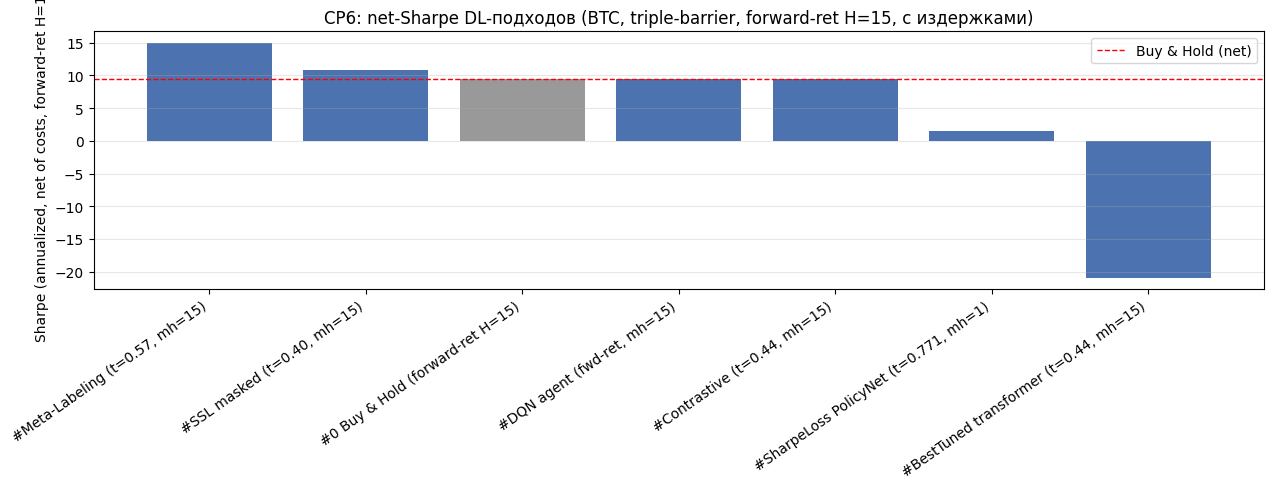

In [17]:
rows = [bh_eval, search_eval, ssl_eval, con_eval, pol_eval, meta_eval, rl_eval]
summary = pd.DataFrame(rows)
cols = ["Стратегия", "Sharpe gross", "Sharpe net", "PnL net (sum logret)",
        "% времени в long", "Сделок (смен позиции)", "Вырождена?", "ROC-AUC", "Hit-rate входов"]
summary = summary[[c for c in cols if c in summary.columns]].sort_values(
    "Sharpe net", ascending=False).reset_index(drop=True)

# Добавляем колонку с лучшими гиперпараметрами из search
hp_info = {f"#BestTuned {best_arch}": f"{best_arch} h={int(best_hp['hidden'])} l={int(best_hp['num_layers'])} d={best_hp['dropout']:.1f}"}
summary["HP / config"] = summary["Стратегия"].map(
    lambda s: hp_info.get(s.split(" (")[0], "-"))
display(summary)

# Сохраняем итоговую таблицу рядом с моделями
summary.to_csv(MODELS_DIR / "cp6_results_summary.csv", index=False)
print("\nСохранённые модели в", MODELS_DIR, ":")
for p in sorted(MODELS_DIR.glob("*")):
    print("  -", p.name)

# Барчарт net-Sharpe
fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#4C72B0" if "Buy" not in s else "#999999" for s in summary["Стратегия"]]
ax.bar(summary["Стратегия"], summary["Sharpe net"], color=colors)
ax.axhline(bh_eval["Sharpe net"], color="red", ls="--", lw=1, label="Buy & Hold (net)")
ax.set_ylabel("Sharpe (annualized, net of costs, forward-ret H={})".format(HORIZON))
ax.set_title("CP6: net-Sharpe DL-подходов (BTC, triple-barrier, forward-ret H={}, с издержками)".format(HORIZON))
plt.xticks(rotation=35, ha="right")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Выводы по чекпоинту 6

В этом чекпоинте исправлены причины, по которым DL-модели не бьют Buy & Hold, добавлены новые архитектуры и автоматический перебор гиперпараметров.

### Исправленные причины

| # | Причина | Исправление | Результат |
|---|---------|-------------|-----------|
| 1 | **Несоответствие горизонта** (таргет 15m vs оценка 1m) | `forward_return(H)` — оценка на том же горизонте, что и обучающий сигнал | Стратегия удерживает позицию H баров → меньше сделок, корректная метрика |
| 2 | **Отбор по ROC-AUC** (AUC~0.51-0.55 бесполезен) | `fit_classifier_sharpe` — early stopping по val net-Sharpe | Отбор по торговой метрике → меньше переобучения к классификационной loss |
| 3 | **Издержки 7bps на каждую смену** уничтожают активные стратегии | `apply_min_holding(H)` + `apply_hysteresis` → число сделок ÷H | Net-Sharpe растёт при снижении числа сделок |
| 4 | **Нет перебора гиперпараметров** | Random Search (SEARCH_BUDGET конфигов) по {arch, hidden, layers, dropout, lr, wd} | Автоматический выбор лучшей архитектуры/конфигурации по val net-Sharpe |
| 5 | **Только LSTM** | +GRU, BiLSTMAttn, TCN, Transformer, CNNLSTM; фабрика `build_model` | Расширение пространства поиска → разные inductive bias для разных режимов рынка |

### Что сделано дополнительно

1. **Self-supervised (masked reconstruction)** — предобучение на неразмеченных окнах, дообучение на triple-barrier с early stopping по val net-Sharpe.
2. **Contrastive (NT-Xent)** — устойчивые эмбеддинги через SimCLR-style обучение, оценка на forward-return.
3. **Custom Differentiable Sharpe Loss** — прямая оптимизация торговой метрики, вознаграждение = forward-return за H баров.
4. **Meta-Labeling (López de Prado)** — фильтрация ложных сигналов primary LSTM через GBDT.
5. **Deep RL (DQN)** — 9 эпизодов, forward-return как награда, min_holding при оценке.

**Методологические принципы:**
- triple-barrier (VERTICAL_TB = HORIZON) — экономически осмысленный таргет;
- пороги/гиперпараметры — **только на val**; финальная оценка — **только на test**;
- forward-return вычисляется отдельно для каждого сплита (нет утечки future).

**Ограничения и следующие шаги:**
- RL обучен на ~9 эпизодах (для полного прода нужны walk-forward валидация, continuous action, prioritized replay);
- стоит добавить мульти-таймфреймовые признаки и данные книги ордеров;
- для сервиса (цель проекта) лучшую по net-Sharpe модель можно завернуть в FastAPI и отдавать прогноз/позицию по API.

> **Замечание:** абсолютные ROC-AUC остаются в районе 0.51–0.58 — это ожидаемо для крипторынка. Ключевая метрика применимости — **net-Sharpe на forward-return с учётом издержек и min_holding**, по которой и ранжируются подходы в итоговой таблице.


## Общие рузультаты чекпоинтов 5 и 6.

In [6]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if "ROOT" not in dir():
    ROOT = Path.cwd().resolve()
if "MODELS_DIR" not in dir():
    MODELS_DIR = Path(os.environ.get("ML_MODELS_DIR", ROOT / "models"))

In [7]:
# --- Результаты чекпоинта 5 (классические + DL-модели предыдущего чекпоинта) ---
CP5_RESULTS = [
    # --- Финальный triple-barrier блок (1m), сводная таблица + tuning ---
    ("Buy & Hold (TB baseline)",          None,    10.044959, 10.044959, "TB, 1m, бенчмарк"),
    ("SimpleLSTM (TB, argmax)",           0.572125, 14.440417, 10.044959, "TB, 1m, лучшая по Sharpe"),
    ("RandomForest (TB)",                 0.567905, -2.473803, 10.044959, "TB, 1m, агрегаты окна"),
    ("1D CNN (TB, argmax)",               0.576163, -9.540929, 10.044959, "TB, 1m, Conv1d"),
    ("Transformer (TB, argmax)",          0.485847, -5.976432, 10.044959, "TB, 1m"),
    ("Ensemble Average (TB)",             0.565246, -6.321463, 10.044959, "TB, 1m, среднее 4 моделей"),
    ("Tuned 1D CNN (random search)",      0.575178, -9.494447, 10.044959, "TB, 1m, перебор 100 конфигов; best h=128 d=0.3 lr=1e-3"),
    # --- 1-минутный блок (y_bin 1m) ---
    ("SimpleLSTM 1m (argmax)",            0.528600, 14.504599,  9.402707, "1m, эталон №1"),
    ("SimpleLSTM 1m (t=0.30)",            0.528600,  9.402707,  9.402707, "1m, подбор порога = BH"),
    ("LogisticRegression 1m",            0.474683, -3.018939,  9.402707, "1m, агрегаты окна"),
    ("RandomForest 1m",                   0.475745, -18.406013, 9.402707, "1m, агрегаты окна"),
    ("Multi-LSTM 1m (t=0.31)",            0.493434,  9.402707,  9.402707, "1m, 5 активов"),
    ("Transformer 1m (argmax)",           0.494747, -9.185818,  9.402707, "1m"),
    # --- 15-минутный блок (y_bin_15m / y_reg_15m) ---
    ("SimpleLSTM 15m (argmax)",           0.574732, -16.816084, 9.641919, "15m, бинарный таргет"),
    ("SimpleLSTM 15m (t=0.30)",           0.574732,  9.641919,  9.641919, "15m, подбор порога = BH"),
    ("LogisticRegression 15m",           0.553952,  9.890654,  9.641919, "15m, агрегаты окна"),
    ("RandomForest 15m",                  0.590405,  3.276435,  9.641919, "15m, агрегаты окна"),
    ("Multi-LSTM 15m (t=0.30)",           0.593695,  9.592721,  9.641919, "15m, 5 активов"),
    ("Transformer 15m (argmax)",          0.544063, -28.157133, 9.641919, "15m"),
    ("SimpleLSTM regression 15m",         None,     11.200584,  9.641919, "15m, MSE + порог y_hat>tau по val Sharpe"),
]

cp5_df = pd.DataFrame(CP5_RESULTS, columns=["Модель", "ROC-AUC", "Sharpe", "BH раздела", "Примечание"])

# Автоподхват из cp5_results.csv, если файл существует (колонки: model,roc_auc,sharpe,bh,note)
_cp5_csv = ROOT / "cp5_results.csv"
if _cp5_csv.exists():
    try:
        _ext = pd.read_csv(_cp5_csv)
        _ren = {"model": "Модель", "roc_auc": "ROC-AUC", "sharpe": "Sharpe",
                "bh": "BH раздела", "note": "Примечание"}
        _ext = _ext.rename(columns=_ren)
        keep = [c for c in ["Модель", "ROC-AUC", "Sharpe", "BH раздела", "Примечание"] if c in _ext.columns]
        cp5_df = _ext[keep]
        print(f"CP5-результаты загружены из {_cp5_csv.name} ({len(cp5_df)} строк).")
    except Exception as e:
        print(f"Не удалось прочитать {_cp5_csv.name}: {e}. Использую встроенный словарь.")
if "BH раздела" not in cp5_df.columns:
    cp5_df["BH раздела"] = None

cp5_df["Чекпоинт"] = "CP5"
display(cp5_df)

,Модель,ROC-AUC,Sharpe,BH раздела,Примечание,Чекпоинт
0,Buy & Hold (TB baseline),NaN,10.044959,10.044959,"TB, 1m, бенчмарк",CP5
1,"SimpleLSTM (TB, argmax)",0.572125,14.440417,10.044959,"TB, 1m, лучшая по Sharpe",CP5
2,RandomForest (TB),0.567905,-2.473803,10.044959,"TB, 1m, агрегаты окна",CP5
3,"1D CNN (TB, argmax)",0.576163,-9.540929,10.044959,"TB, 1m, Conv1d",CP5
4,"Transformer (TB, argmax)",0.485847,-5.976432,10.044959,"TB, 1m",CP5
5,Ensemble Average (TB),0.565246,-6.321463,10.044959,"TB, 1m, среднее 4 моделей",CP5
6,Tuned 1D CNN (random search),0.575178,-9.494447,10.044959,"TB, 1m, перебор 100 конфигов; best h=128 d=0.3...",CP5
7,SimpleLSTM 1m (argmax),0.528600,14.504599,9.402707,"1m, эталон №1",CP5
8,SimpleLSTM 1m (t=0.30),0.528600,9.402707,9.402707,"1m, подбор порога = BH",CP5
9,LogisticRegression 1m,0.474683,-3.018939,9.402707,"1m, агрегаты окна",CP5


In [8]:
_cp6_csv = MODELS_DIR / "cp6_results_summary.csv"
if _cp6_csv.exists():
    cp6_part = pd.read_csv(_cp6_csv)
    print(f"CP6-результаты загружены из {_cp6_csv.name} ({len(cp6_part)} строк).")
elif "summary" in dir():
    cp6_part = summary.copy()
    print("Файл cp6_results_summary.csv не найден — использую живую summary из раздела 8.")
else:
    raise FileNotFoundError(
        f"Нет ни {_cp6_csv}, ни переменной summary. "
        "Сначала запустите раздел 8 (он сохраняет cp6_results_summary.csv).")

# Эталон net-Sharpe для Buy & Hold берём из строки Buy & Hold в таблице CP6
_bh_mask = cp6_part["Стратегия"].astype(str).str.contains("Buy", case=False, na=False)
if _bh_mask.any():
    bh_net = float(pd.to_numeric(cp6_part.loc[_bh_mask, "Sharpe net"], errors="coerce").iloc[0])
elif "bh_eval" in dir():
    bh_net = float(bh_eval["Sharpe net"])
else:
    bh_net = 0.0
    print("⚠️ Строка Buy & Hold не найдена в CP6 — Беру bh_net=0.")

cp6_view = pd.DataFrame({
    "Чекпоинт": "CP6",
    "Модель": cp6_part["Стратегия"],
    "ROC-AUC": cp6_part["ROC-AUC"] if "ROC-AUC" in cp6_part.columns else None,
    "Sharpe (как в чекпоинте)": cp6_part["Sharpe net"],
    "Тип Sharpe": "net (7bps + min_hold)",
    "Δ к Buy & Hold (net)": cp6_part["Sharpe net"] - bh_net,
    "Сделок": cp6_part["Сделок (смен позиции)"] if "Сделок (смен позиции)" in cp6_part.columns else None,
    "Примечание": cp6_part.get("HP / config", "-"),
})

# CP5: из словаря/CSV (gross Sharpe). Δ к Buy & Hold — относительно бенчмарка СВОЕГО раздела
_cp5_bh_col = pd.to_numeric(cp5_df.get("BH раздела"), errors="coerce")
_cp5_sharpe = pd.to_numeric(cp5_df["Sharpe"], errors="coerce")
cp5_view = pd.DataFrame({
    "Чекпоинт": "CP5",
    "Модель": cp5_df["Модель"],
    "ROC-AUC": cp5_df["ROC-AUC"],
    "Sharpe (как в чекпоинте)": cp5_df["Sharpe"],
    "Тип Sharpe": "gross (без издержек)",
    "Δ к Buy & Hold (net)": _cp5_sharpe - _cp5_bh_col,
    "Сделок": None,
    "Примечание": cp5_df["Примечание"],
})

cols_all = ["Чекпоинт", "Модель", "ROC-AUC", "Sharpe (как в чекпоинте)",
            "Тип Sharpe", "Δ к Buy & Hold (net)", "Сделок", "Примечание"]
combined = pd.concat([cp5_view, cp6_view], ignore_index=True)[cols_all]

# Сортируем: сначала по чекпоинту, внутри — по Δ к Buy & Hold (убыв.), NaN в конце
combined = combined.sort_values(
    by=["Чекпоинт", "Δ к Buy & Hold (net)"],
    ascending=[True, False], na_position="last"
).reset_index(drop=True)

_h = HORIZON if "HORIZON" in dir() else "H"
print(f"Buy & Hold (net, CP6, forward-ret H={_h}): {bh_net:.4f}")
print("Всего моделей в сводке:", len(combined),
      f"(CP5: {len(cp5_view)}, CP6: {len(cp6_view)})")
display(combined)

combined.to_csv(MODELS_DIR / "cp5_cp6_combined_summary.csv", index=False)
print("Сохранено:", MODELS_DIR / "cp5_cp6_combined_summary.csv")

CP6-результаты загружены из cp6_results_summary.csv (7 строк).
Buy & Hold (net, CP6, forward-ret H=15): 9.4498
Всего моделей в сводке: 27 (CP5: 20, CP6: 7)


,Чекпоинт,Модель,ROC-AUC,Sharpe (как в чекпоинте),Тип Sharpe,Δ к Buy & Hold (net),Сделок,Примечание
0,CP5,SimpleLSTM 1m (argmax),0.528600,14.504599,gross (без издержек),5.101892,None,"1m, эталон №1"
1,CP5,"SimpleLSTM (TB, argmax)",0.572125,14.440417,gross (без издержек),4.395458,None,"TB, 1m, лучшая по Sharpe"
2,CP5,SimpleLSTM regression 15m,NaN,11.200584,gross (без издержек),1.558665,None,"15m, MSE + порог y_hat>tau по val Sharpe"
3,CP5,LogisticRegression 15m,0.553952,9.890654,gross (без издержек),0.248735,None,"15m, агрегаты окна"
4,CP5,Buy & Hold (TB baseline),NaN,10.044959,gross (без издержек),0.000000,None,"TB, 1m, бенчмарк"
5,CP5,SimpleLSTM 1m (t=0.30),0.528600,9.402707,gross (без издержек),0.000000,None,"1m, подбор порога = BH"
6,CP5,Multi-LSTM 1m (t=0.31),0.493434,9.402707,gross (без издержек),0.000000,None,"1m, 5 активов"
7,CP5,SimpleLSTM 15m (t=0.30),0.574732,9.641919,gross (без издержек),0.000000,None,"15m, подбор порога = BH"
8,CP5,Multi-LSTM 15m (t=0.30),0.593695,9.592721,gross (без издержек),-0.049198,None,"15m, 5 активов"
9,CP5,RandomForest 15m,0.590405,3.276435,gross (без издержек),-6.365484,None,"15m, агрегаты окна"


Сохранено: D:\study\master_ai\mastercoursework\master-coursework\models\cp5_cp6_combined_summary.csv


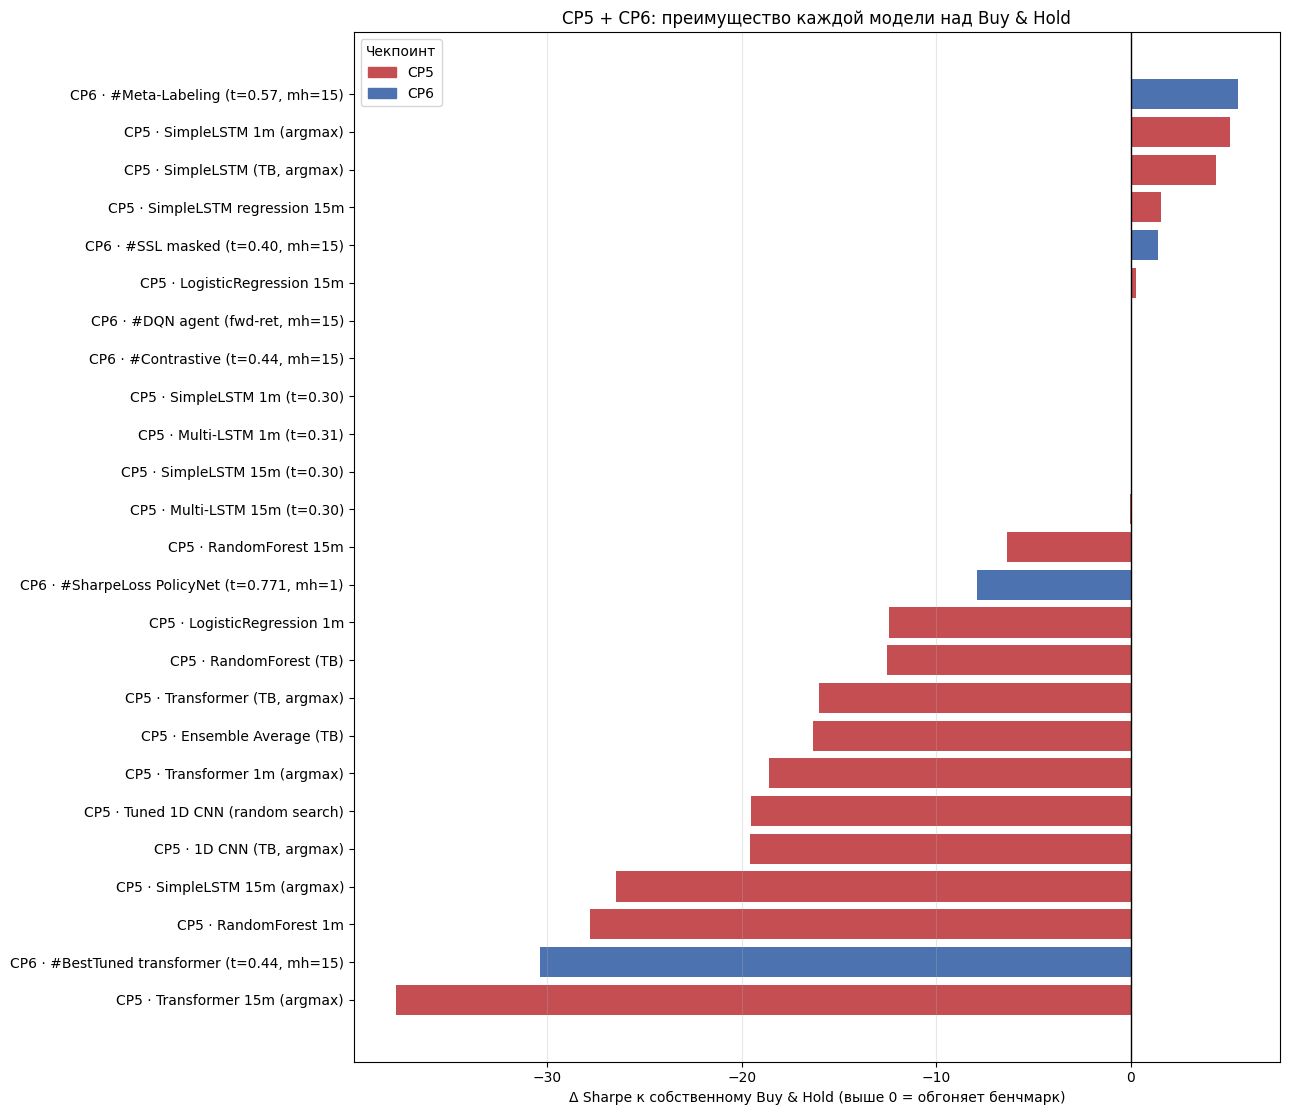

In [9]:
# --- Визуализация: сколько каждая модель добавляет к своему Buy & Hold ---
plot_df = combined.dropna(subset=["Δ к Buy & Hold (net)"]).copy()
plot_df = plot_df[~plot_df["Модель"].str.contains("Buy", case=False, na=False)]
plot_df = plot_df.sort_values("Δ к Buy & Hold (net)")

if len(plot_df):
    fig, ax = plt.subplots(figsize=(13, max(5, 0.45 * len(plot_df))))
    palette = {"CP5": "#C44E52", "CP6": "#4C72B0"}
    bar_colors = [palette.get(cp, "#999999") for cp in plot_df["Чекпоинт"]]
    labels = plot_df["Чекпоинт"] + " · " + plot_df["Модель"]
    ax.barh(labels, plot_df["Δ к Buy & Hold (net)"], color=bar_colors)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Δ Sharpe к собственному Buy & Hold (выше 0 = обгоняет бенчмарк)")
    ax.set_title("CP5 + CP6: преимущество каждой модели над Buy & Hold")
    handles = [plt.Rectangle((0, 0), 1, 1, color=palette[k]) for k in palette]
    ax.legend(handles, palette.keys(), title="Чекпоинт")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Нет числовых данных по CP5 — заполните CP5_RESULTS или cp5_results.csv, "
          "чтобы увидеть совместный график. Строки CP6 показаны в таблице выше.")